In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 86
==================================================
Week: 13 of 24
Day: 86 of 168
Date: January 21, 2026 (Tuesday)
Topic: Stock Price Predictor - Feature Engineering for Time Series

Week 13 Progress:
✅ Day 85: Time series fundamentals & data collection (COMPLETE!)
🔄 Day 86: Feature engineering (RSI, MACD, indicators) (TODAY!)
⬜ Day 87: LSTM model for time series
⬜ Day 88: Model optimization & backtesting
⬜ Day 89: Interactive dashboard (Streamlit)
⬜ Day 90: Advanced features & deployment
⬜ Day 91: Final testing & portfolio addition

Progress: 14% (1/7 days)

==================================================
🎯 Week 13 Project: Stock Price Predictor with LSTM
Building on Day 85's foundation, today we engineer features!

🎯 Today's Learning Objectives:
1. Implement Technical Indicators
   - RSI (Relative Strength Index)
   - MACD (Moving Average Convergence Divergence)
   - Bollinger Bands
   - Stochastic Oscillator
   - ATR (Average True Range)

2. Create Lag Features
   - Price lags (t-1 to t-30)
   - Volume lags
   - Returns lags
   - Optimal lookback window

3. Build Rolling Statistics
   - Rolling mean (7, 14, 30 days)
   - Rolling std (volatility)
   - Rolling min/max
   - Expanding statistics

4. Preprocess for LSTM
   - Handle missing values
   - Feature scaling (MinMax)
   - Create sequences (60 days → predict day 61)
   - Train/val/test split (chronological)

📚 Today's Structure:
Part 1 (2h): Technical Indicators Implementation
Part 2 (1.5h): Lag Features & Rolling Statistics
Part 3 (2h): Data Preprocessing & Sequence Creation
Part 4 (1h): Feature Analysis & Summary

🎯 SUCCESS CRITERIA:
✅ Implement 10+ technical indicators
✅ Create 20-30 total features per stock
✅ Handle missing values properly
✅ Scale features for LSTM input
✅ Create sequences (X: 60 days, y: next day)
✅ Split data chronologically (70/15/15)
✅ Visualize feature correlations
✅ Save processed data for Day 87

==================================================
"""

In [1]:
# ==================================================
# INSTALL REQUIRED LIBRARIES
# ==================================================

import sys

print("Installing required libraries...")
print("=" * 80)

# Install scikit-learn first (it will use compatible versions)
!pip install scikit-learn -q

print("\n✅ Libraries installed successfully!")
print("=" * 80)

# ==================================================
# IMPORT LIBRARIES
# ==================================================

print("\n" + "=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

# Core libraries
import os
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# Yahoo Finance API
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Machine Learning - Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Set random seed
np.random.seed(42)

# Configure matplotlib for Colab
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['figure.dpi'] = 100

print("\n✅ All libraries imported successfully!")
print(f"✅ pandas version: {pd.__version__}")
print(f"✅ numpy version: {np.__version__}")
print("✅ scikit-learn ready for preprocessing!")
print("=" * 80)

# ==================================================
# INSTALL PANDAS-TA (AFTER IMPORTS)
# ==================================================

print("\n" + "=" * 80)
print("📊 INSTALLING TECHNICAL ANALYSIS LIBRARY")
print("=" * 80)

!pip install pandas-ta -q

# Import pandas-ta
import pandas_ta as ta

print("\n✅ pandas-ta installed and imported!")
print("=" * 80)

Installing required libraries...

✅ Libraries installed successfully!

📚 IMPORTING LIBRARIES

✅ All libraries imported successfully!
✅ pandas version: 2.2.2
✅ numpy version: 2.0.2
✅ scikit-learn ready for preprocessing!

📊 INSTALLING TECHNICAL ANALYSIS LIBRARY
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 14.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-col

In [2]:
print("\n" + "=" * 80)
print("📊 PART 1: TECHNICAL INDICATORS IMPLEMENTATION")
print("=" * 80)


📊 PART 1: TECHNICAL INDICATORS IMPLEMENTATION


In [4]:
# ==================================================
# LOAD DATA FROM DAY 85
# ==================================================

print("\n" + "=" * 80)
print("📂 LOADING DATA FROM DAY 85")
print("=" * 80)

"""
📖 THEORY: Data Continuity

We'll reload the stock data from Day 85 to ensure consistency.
This simulates a real ML workflow where we save/load data between sessions.
"""

print("\n⏱️ Re-downloading stock data...")

# Define stocks (same as Day 85)
stocks = {
    'TSLA': 'Tesla Inc.',
    'NVDA': 'NVIDIA Corporation',
    'AAPL': 'Apple Inc.',
    'MSFT': 'Microsoft Corporation',
    'JNJ': 'Johnson & Johnson',
}

# Date range (5 years)
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Download data
stock_data = {}

for ticker, name in stocks.items():
    print(f"⏳ Loading {ticker}...")
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=True
    )

    if len(df) > 0:
        # Flatten multi-index columns if they exist
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df['Ticker'] = ticker
        stock_data[ticker] = df
        print(f"   ✅ {len(df)} days loaded")

print(f"\n✅ Data loaded for {len(stock_data)} stocks!")
print("=" * 80)


📂 LOADING DATA FROM DAY 85

⏱️ Re-downloading stock data...
⏳ Loading TSLA...
   ✅ 1254 days loaded
⏳ Loading NVDA...
   ✅ 1254 days loaded
⏳ Loading AAPL...
   ✅ 1254 days loaded
⏳ Loading MSFT...
   ✅ 1254 days loaded
⏳ Loading JNJ...
   ✅ 1254 days loaded

✅ Data loaded for 5 stocks!



EXERCISE 1.1: Moving Averages (SMA & EMA)

⏱️ Calculating moving averages for all stocks...
✅ TSLA: Moving averages calculated
✅ NVDA: Moving averages calculated
✅ AAPL: Moving averages calculated
✅ MSFT: Moving averages calculated
✅ JNJ: Moving averages calculated


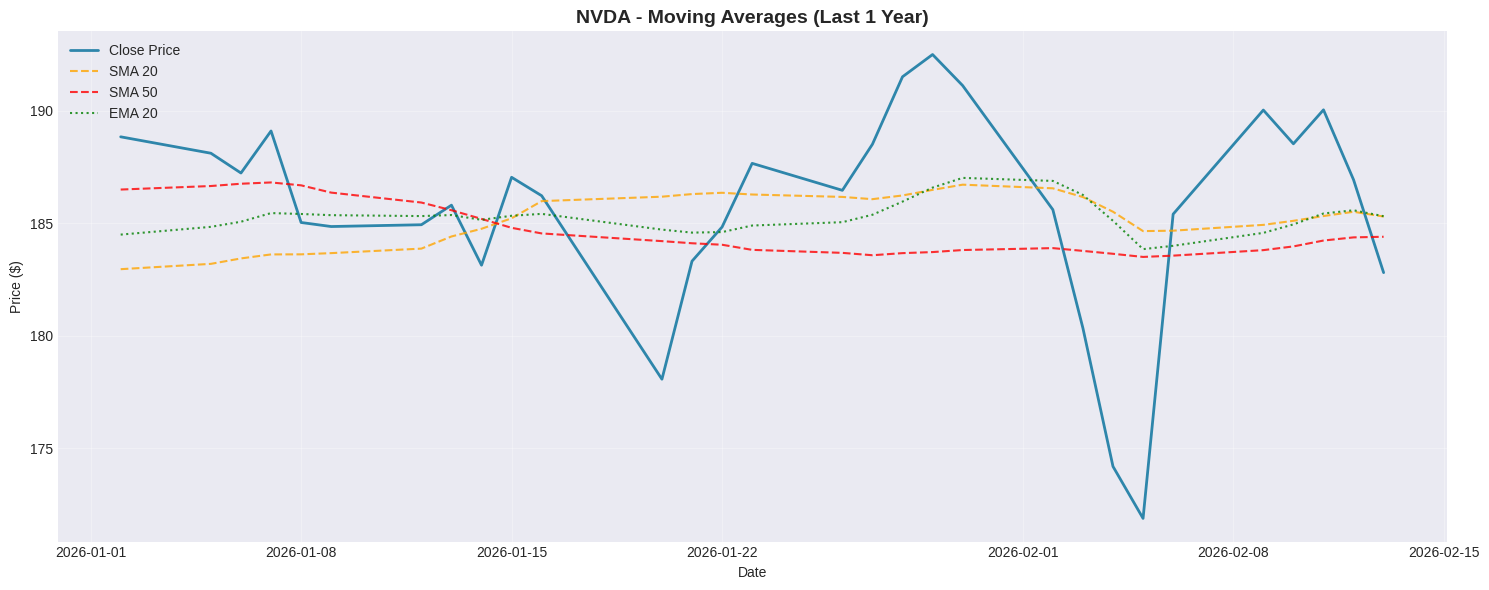


📊 Moving Averages Summary:

TSLA:
   SMA_20 (latest): $424.73
   SMA_50 (latest): $443.95
   EMA_20 (latest): $424.83
   Signal: 🔴 Bearish (SMA20 < SMA50)

NVDA:
   SMA_20 (latest): $185.30
   SMA_50 (latest): $184.41
   EMA_20 (latest): $185.32
   Signal: 🟢 Bullish (SMA20 > SMA50)

AAPL:
   SMA_20 (latest): $262.09
   SMA_50 (latest): $267.25
   EMA_20 (latest): $265.65
   Signal: 🔴 Bearish (SMA20 < SMA50)

MSFT:
   SMA_20 (latest): $432.49
   SMA_50 (latest): $460.94
   EMA_20 (latest): $427.61
   Signal: 🔴 Bearish (SMA20 < SMA50)

JNJ:
   SMA_20 (latest): $230.18
   SMA_50 (latest): $216.74
   EMA_20 (latest): $231.49
   Signal: 🟢 Bullish (SMA20 > SMA50)

✅ Exercise 1.1 Complete!


In [5]:
# ==================================================
# EXERCISE 1.1: MOVING AVERAGES (SMA & EMA)
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.1: Moving Averages (SMA & EMA)")
print("=" * 80)

"""
📖 THEORY: Moving Averages

Moving averages smooth out price data to identify trends.

1. SMA (Simple Moving Average):
   - Average of last N closing prices
   - Equal weight to all periods
   - Slower to react to price changes
   - Formula: SMA = (P1 + P2 + ... + PN) / N

2. EMA (Exponential Moving Average):
   - More weight to recent prices
   - Faster to react to price changes
   - More popular among traders
   - Formula: EMA = Price × k + EMA(yesterday) × (1-k)
     where k = 2/(N+1)

Common Periods:
- Short term: 9, 20 days
- Medium term: 50 days
- Long term: 100, 200 days

Trading Signals:
- Golden Cross: 50-day SMA crosses ABOVE 200-day → Bullish!
- Death Cross: 50-day SMA crosses BELOW 200-day → Bearish!
"""

print("\n⏱️ Calculating moving averages for all stocks...")

for ticker, df in stock_data.items():
    # SMA - Simple Moving Averages
    df['SMA_9'] = ta.sma(df['Close'], length=9)
    df['SMA_20'] = ta.sma(df['Close'], length=20)
    df['SMA_50'] = ta.sma(df['Close'], length=50)
    df['SMA_200'] = ta.sma(df['Close'], length=200)

    # EMA - Exponential Moving Averages
    df['EMA_9'] = ta.ema(df['Close'], length=9)
    df['EMA_20'] = ta.ema(df['Close'], length=20)
    df['EMA_50'] = ta.ema(df['Close'], length=50)

    print(f"✅ {ticker}: Moving averages calculated")

# Visualize for NVDA
ticker = 'NVDA'
df = stock_data[ticker]
df_plot = df.last('1Y')

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_plot.index, df_plot['Close'], label='Close Price', linewidth=2, color='#2E86AB')
ax.plot(df_plot.index, df_plot['SMA_20'], label='SMA 20', linestyle='--', alpha=0.8, color='orange')
ax.plot(df_plot.index, df_plot['SMA_50'], label='SMA 50', linestyle='--', alpha=0.8, color='red')
ax.plot(df_plot.index, df_plot['EMA_20'], label='EMA 20', linestyle=':', alpha=0.8, color='green')

ax.set_title(f'{ticker} - Moving Averages (Last 1 Year)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Moving Averages Summary:")
for ticker, df in stock_data.items():
    print(f"\n{ticker}:")
    print(f"   SMA_20 (latest): ${float(df['SMA_20'].iloc[-1]):.2f}")
    print(f"   SMA_50 (latest): ${float(df['SMA_50'].iloc[-1]):.2f}")
    print(f"   EMA_20 (latest): ${float(df['EMA_20'].iloc[-1]):.2f}")

    # Golden/Death Cross signal
    sma20 = float(df['SMA_20'].iloc[-1])
    sma50 = float(df['SMA_50'].iloc[-1])
    signal = "🟢 Bullish (SMA20 > SMA50)" if sma20 > sma50 else "🔴 Bearish (SMA20 < SMA50)"
    print(f"   Signal: {signal}")

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.2: RSI - Relative Strength Index

⏱️ Calculating RSI for all stocks...
✅ TSLA: RSI calculated
✅ NVDA: RSI calculated
✅ AAPL: RSI calculated
✅ MSFT: RSI calculated
✅ JNJ: RSI calculated


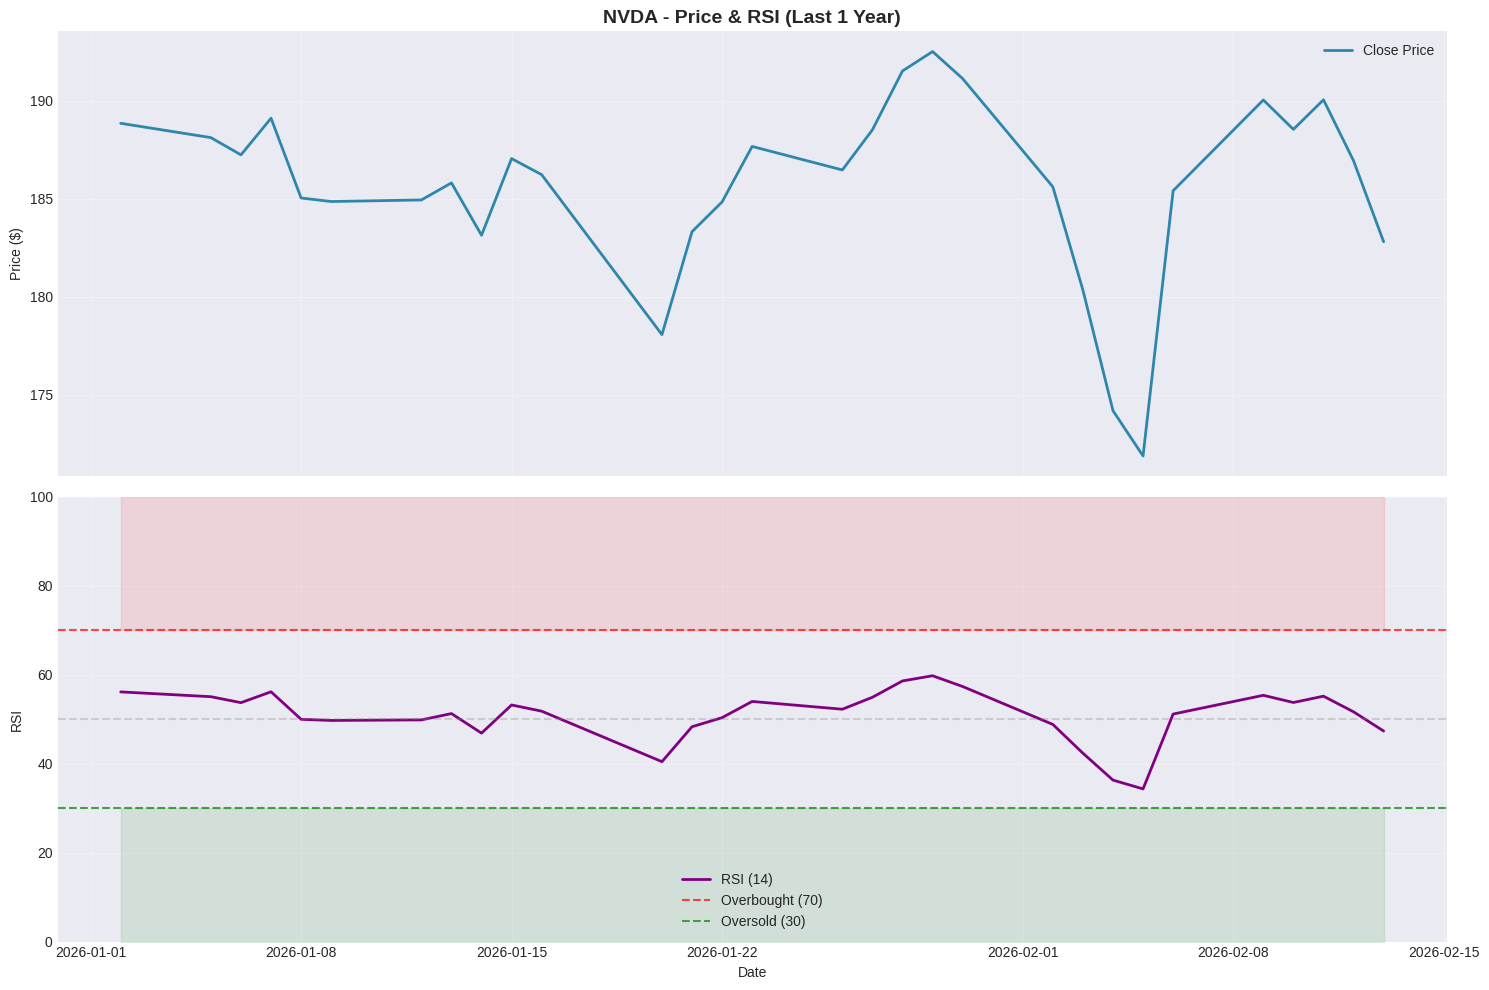


📊 Current RSI Signals:

TSLA:
   RSI (14): 44.92
   Signal: ⚪ NEUTRAL

NVDA:
   RSI (14): 47.33
   Signal: ⚪ NEUTRAL

AAPL:
   RSI (14): 39.59
   Signal: ⚪ NEUTRAL

MSFT:
   RSI (14): 32.39
   Signal: ⚪ NEUTRAL

JNJ:
   RSI (14): 81.74
   Signal: 🔴 OVERBOUGHT - potential sell signal

✅ Exercise 1.2 Complete!


In [6]:
# ==================================================
# EXERCISE 1.2: RSI (RELATIVE STRENGTH INDEX)
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.2: RSI - Relative Strength Index")
print("=" * 80)

"""
📖 THEORY: RSI (Relative Strength Index)

RSI measures momentum - how fast prices are changing.
Developed by J. Welles Wilder in 1978.

Formula:
  RSI = 100 - (100 / (1 + RS))
  RS = Average Gain / Average Loss (over N periods)

Range: 0 to 100

Interpretation:
- RSI > 70: OVERBOUGHT (price may fall soon)
- RSI < 30: OVERSOLD (price may rise soon)
- RSI = 50: Neutral

Common Period: 14 days

Why RSI matters for LSTM:
- Captures momentum signals
- Identifies potential reversals
- Widely used by traders (self-fulfilling)
"""

print("\n⏱️ Calculating RSI for all stocks...")

for ticker, df in stock_data.items():
    # RSI with standard 14-period
    df['RSI_14'] = ta.rsi(df['Close'], length=14)
    print(f"✅ {ticker}: RSI calculated")

# Visualize RSI for NVDA
ticker = 'NVDA'
df = stock_data[ticker]
df_plot = df.last('1Y')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Price
ax1.plot(df_plot.index, df_plot['Close'], label='Close Price', linewidth=2, color='#2E86AB')
ax1.set_title(f'{ticker} - Price & RSI (Last 1 Year)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# RSI
ax2.plot(df_plot.index, df_plot['RSI_14'], label='RSI (14)', linewidth=2, color='purple')
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.3)
ax2.fill_between(df_plot.index, 70, 100, alpha=0.1, color='red')
ax2.fill_between(df_plot.index, 0, 30, alpha=0.1, color='green')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Current RSI Signals:")
for ticker, df in stock_data.items():
    rsi = float(df['RSI_14'].iloc[-1])

    if rsi > 70:
        signal = "🔴 OVERBOUGHT - potential sell signal"
    elif rsi < 30:
        signal = "🟢 OVERSOLD - potential buy signal"
    else:
        signal = "⚪ NEUTRAL"

    print(f"\n{ticker}:")
    print(f"   RSI (14): {rsi:.2f}")
    print(f"   Signal: {signal}")

print("\n✅ Exercise 1.2 Complete!")
print("=" * 80)


EXERCISE 1.3: MACD - Moving Average Convergence Divergence

⏱️ Calculating MACD for all stocks...
✅ TSLA: MACD calculated
✅ NVDA: MACD calculated
✅ AAPL: MACD calculated
✅ MSFT: MACD calculated
✅ JNJ: MACD calculated


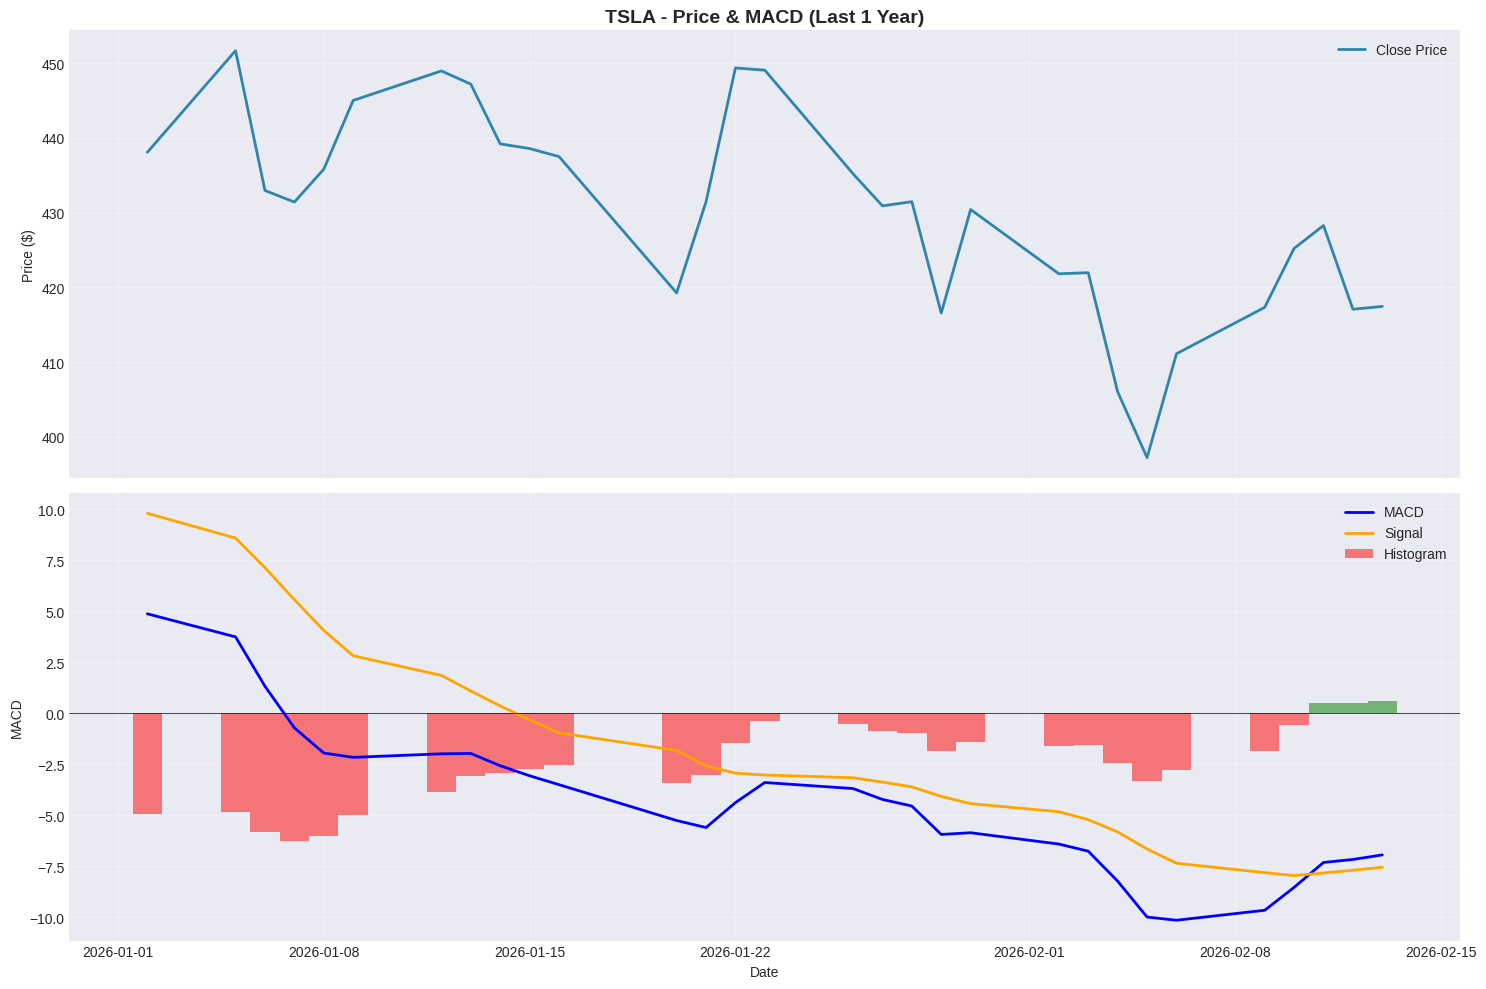


📊 Current MACD Signals:

TSLA:
   MACD: -6.9375
   Signal: -7.5407
   Histogram: 0.6032
   Trend: 🟢 Bullish (MACD > Signal)

NVDA:
   MACD: 0.1086
   Signal: 0.0280
   Histogram: 0.0807
   Trend: 🟢 Bullish (MACD > Signal)

AAPL:
   MACD: 1.1845
   Signal: 1.1967
   Histogram: -0.0121
   Trend: 🔴 Bearish (MACD < Signal)

MSFT:
   MACD: -18.7645
   Signal: -16.7149
   Histogram: -2.0496
   Trend: 🔴 Bearish (MACD < Signal)

JNJ:
   MACD: 8.0754
   Signal: 7.2229
   Histogram: 0.8525
   Trend: 🟢 Bullish (MACD > Signal)

✅ Exercise 1.3 Complete!


In [7]:
# ==================================================
# EXERCISE 1.3: MACD (MOVING AVERAGE CONVERGENCE DIVERGENCE)
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.3: MACD - Moving Average Convergence Divergence")
print("=" * 80)

"""
📖 THEORY: MACD

MACD shows the relationship between two EMAs.
One of the most popular trend-following indicators!

Components:
1. MACD Line: EMA(12) - EMA(26)
2. Signal Line: EMA(9) of MACD Line
3. Histogram: MACD Line - Signal Line

Interpretation:
- MACD crosses ABOVE Signal → Bullish signal 🟢
- MACD crosses BELOW Signal → Bearish signal 🔴
- Histogram above 0 → Momentum is bullish
- Histogram below 0 → Momentum is bearish
- Divergence: Price goes up but MACD goes down → Warning!

Standard Settings: 12, 26, 9
"""

print("\n⏱️ Calculating MACD for all stocks...")

for ticker, df in stock_data.items():
    # Calculate MACD
    macd_result = ta.macd(df['Close'], fast=12, slow=26, signal=9)

    df['MACD'] = macd_result['MACD_12_26_9']
    df['MACD_Signal'] = macd_result['MACDs_12_26_9']
    df['MACD_Hist'] = macd_result['MACDh_12_26_9']

    print(f"✅ {ticker}: MACD calculated")

# Visualize MACD for TSLA
ticker = 'TSLA'
df = stock_data[ticker]
df_plot = df.last('1Y')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Price
ax1.plot(df_plot.index, df_plot['Close'], label='Close Price', linewidth=2, color='#2E86AB')
ax1.set_title(f'{ticker} - Price & MACD (Last 1 Year)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# MACD
ax2.plot(df_plot.index, df_plot['MACD'], label='MACD', linewidth=2, color='blue')
ax2.plot(df_plot.index, df_plot['MACD_Signal'], label='Signal', linewidth=2, color='orange')

# Histogram with colors
colors = ['green' if v >= 0 else 'red' for v in df_plot['MACD_Hist'].values]
ax2.bar(df_plot.index, df_plot['MACD_Hist'], color=colors, alpha=0.5, label='Histogram', width=1)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_ylabel('MACD')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Current MACD Signals:")
for ticker, df in stock_data.items():
    macd = float(df['MACD'].iloc[-1])
    signal = float(df['MACD_Signal'].iloc[-1])
    hist = float(df['MACD_Hist'].iloc[-1])

    trend = "🟢 Bullish (MACD > Signal)" if macd > signal else "🔴 Bearish (MACD < Signal)"

    print(f"\n{ticker}:")
    print(f"   MACD: {macd:.4f}")
    print(f"   Signal: {signal:.4f}")
    print(f"   Histogram: {hist:.4f}")
    print(f"   Trend: {trend}")

print("\n✅ Exercise 1.3 Complete!")
print("=" * 80)


EXERCISE 1.4: Bollinger Bands

⏱️ Calculating Bollinger Bands for all stocks...

📊 Bollinger Bands columns: ['BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0']
✅ TSLA: Bollinger Bands calculated
✅ NVDA: Bollinger Bands calculated
✅ AAPL: Bollinger Bands calculated
✅ MSFT: Bollinger Bands calculated
✅ JNJ: Bollinger Bands calculated


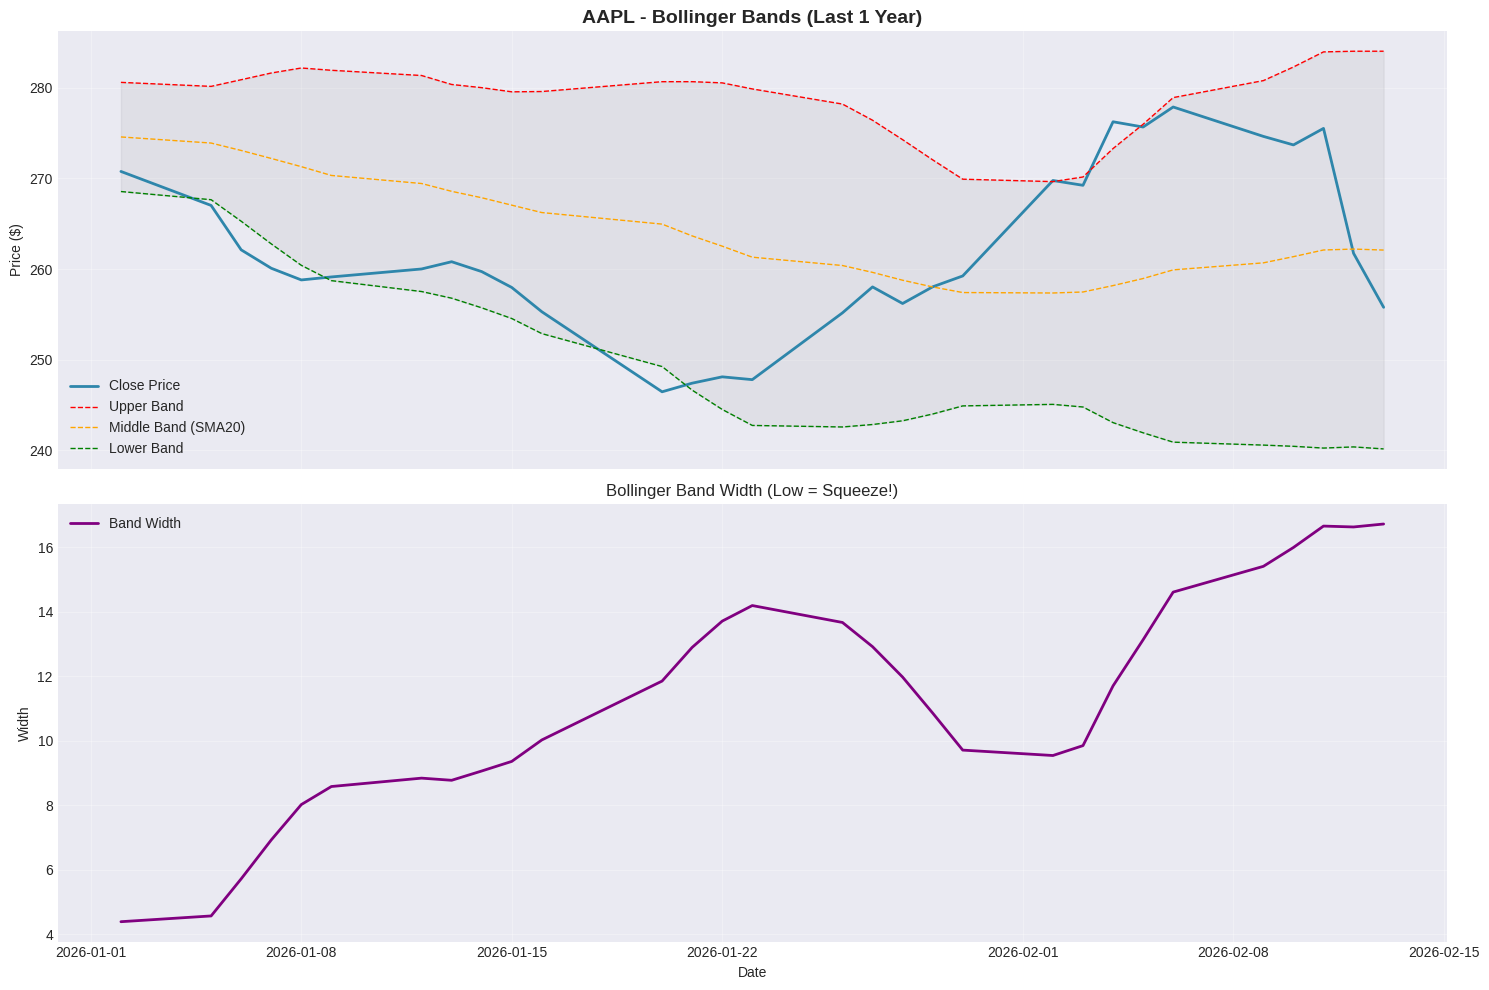


📊 Current Bollinger Band Signals:

TSLA:
   Close: $417.44
   Upper: $450.75 | Lower: $398.70
   Position: 36.00%
   Signal: ⚪ Middle Zone - Neutral

NVDA:
   Close: $182.81
   Upper: $196.47 | Lower: $174.14
   Position: 38.83%
   Signal: ⚪ Middle Zone - Neutral

AAPL:
   Close: $255.78
   Upper: $284.01 | Lower: $240.17
   Position: 35.60%
   Signal: ⚪ Middle Zone - Neutral

MSFT:
   Close: $401.32
   Upper: $490.14 | Lower: $374.84
   Position: 22.96%
   Signal: ⚪ Middle Zone - Neutral

JNJ:
   Close: $243.45
   Upper: $248.59 | Lower: $211.78
   Position: 86.04%
   Signal: 🔴 Near Upper Band - Overbought

✅ Exercise 1.4 Complete!


In [9]:
# ==================================================
# EXERCISE 1.4: BOLLINGER BANDS
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.4: Bollinger Bands")
print("=" * 80)

"""
📖 THEORY: Bollinger Bands

Bollinger Bands measure volatility around a moving average.
Developed by John Bollinger in the 1980s.

Components:
1. Middle Band: 20-day SMA
2. Upper Band: SMA + (2 × Standard Deviation)
3. Lower Band: SMA - (2 × Standard Deviation)

Interpretation:
- Price near Upper Band → Overbought
- Price near Lower Band → Oversold
- Bands NARROW → Low volatility (big move coming!)
- Bands WIDEN → High volatility
"""

print("\n⏱️ Calculating Bollinger Bands for all stocks...")

for ticker, df in stock_data.items():
    # Calculate Bollinger Bands
    bbands = ta.bbands(df['Close'], length=20, std=2)

    # Check actual column names
    if ticker == 'TSLA':
        print(f"\n📊 Bollinger Bands columns: {list(bbands.columns)}")

    # Use the actual column names from output
    bb_cols = bbands.columns.tolist()
    upper_col = [c for c in bb_cols if c.startswith('BBU')][0]
    mid_col = [c for c in bb_cols if c.startswith('BBM')][0]
    lower_col = [c for c in bb_cols if c.startswith('BBL')][0]
    width_col = [c for c in bb_cols if c.startswith('BBB')][0]
    pct_col = [c for c in bb_cols if c.startswith('BBP')][0]

    df['BB_Upper'] = bbands[upper_col]
    df['BB_Middle'] = bbands[mid_col]
    df['BB_Lower'] = bbands[lower_col]
    df['BB_Width'] = bbands[width_col]
    df['BB_Percent'] = bbands[pct_col]

    print(f"✅ {ticker}: Bollinger Bands calculated")

# Visualize for AAPL
ticker = 'AAPL'
df = stock_data[ticker]
df_plot = df.last('1Y')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Price with Bollinger Bands
ax1.plot(df_plot.index, df_plot['Close'], label='Close Price', linewidth=2, color='#2E86AB')
ax1.plot(df_plot.index, df_plot['BB_Upper'], label='Upper Band', linewidth=1, color='red', linestyle='--')
ax1.plot(df_plot.index, df_plot['BB_Middle'], label='Middle Band (SMA20)', linewidth=1, color='orange', linestyle='--')
ax1.plot(df_plot.index, df_plot['BB_Lower'], label='Lower Band', linewidth=1, color='green', linestyle='--')
ax1.fill_between(df_plot.index, df_plot['BB_Upper'], df_plot['BB_Lower'], alpha=0.1, color='gray')
ax1.set_title(f'{ticker} - Bollinger Bands (Last 1 Year)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Band Width
ax2.plot(df_plot.index, df_plot['BB_Width'], label='Band Width', linewidth=2, color='purple')
ax2.set_title('Bollinger Band Width (Low = Squeeze!)', fontsize=12)
ax2.set_ylabel('Width')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Current Bollinger Band Signals:")
for ticker, df in stock_data.items():
    close = float(df['Close'].iloc[-1])
    upper = float(df['BB_Upper'].iloc[-1])
    lower = float(df['BB_Lower'].iloc[-1])
    pct = float(df['BB_Percent'].iloc[-1])

    if pct > 0.8:
        signal = "🔴 Near Upper Band - Overbought"
    elif pct < 0.2:
        signal = "🟢 Near Lower Band - Oversold"
    else:
        signal = "⚪ Middle Zone - Neutral"

    print(f"\n{ticker}:")
    print(f"   Close: ${close:.2f}")
    print(f"   Upper: ${upper:.2f} | Lower: ${lower:.2f}")
    print(f"   Position: {pct:.2%}")
    print(f"   Signal: {signal}")

print("\n✅ Exercise 1.4 Complete!")
print("=" * 80)


EXERCISE 1.5: ATR & Stochastic Oscillator

⏱️ Calculating ATR & Stochastic for all stocks...
✅ TSLA: ATR & Stochastic calculated
✅ NVDA: ATR & Stochastic calculated
✅ AAPL: ATR & Stochastic calculated
✅ MSFT: ATR & Stochastic calculated
✅ JNJ: ATR & Stochastic calculated


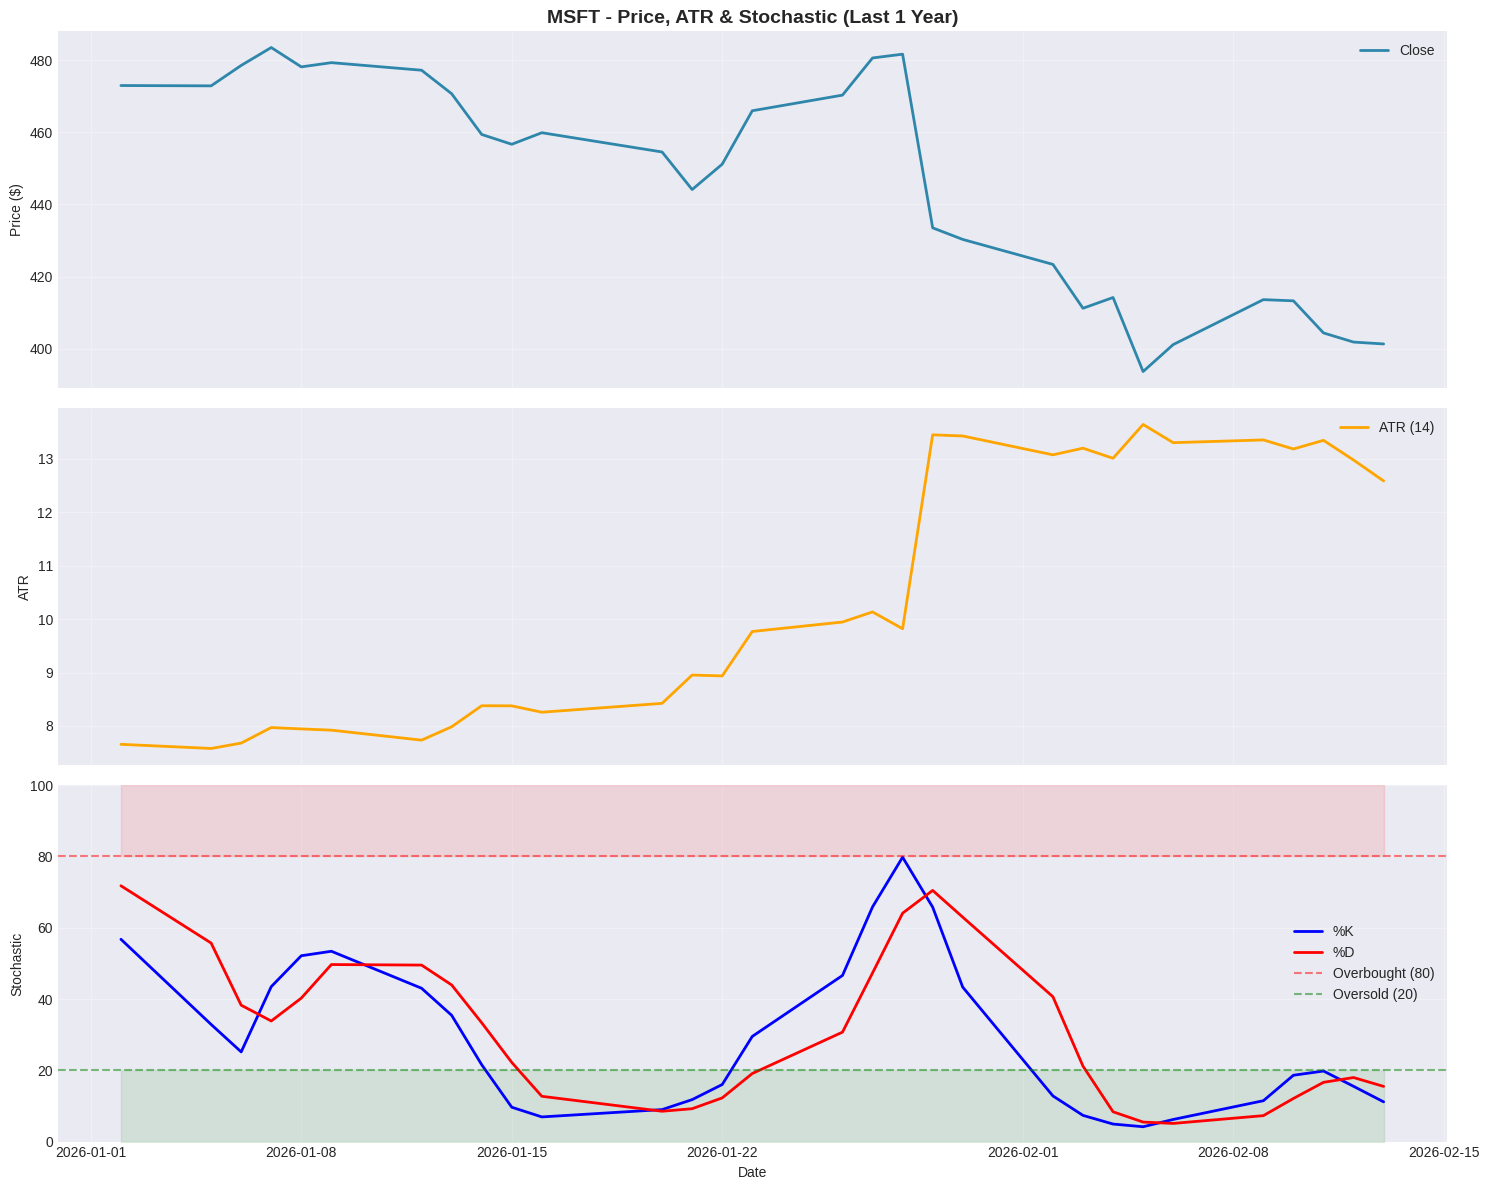


📊 Current ATR & Stochastic Signals:

TSLA:
   ATR (14): $16.07 (3.85% of price)
   Stochastic %K: 56.96
   Stochastic Signal: ⚪ Neutral

NVDA:
   ATR (14): $6.41 (3.51% of price)
   Stochastic %K: 66.37
   Stochastic Signal: ⚪ Neutral

AAPL:
   ATR (14): $6.53 (2.55% of price)
   Stochastic %K: 46.09
   Stochastic Signal: ⚪ Neutral

MSFT:
   ATR (14): $12.59 (3.14% of price)
   Stochastic %K: 11.15
   Stochastic Signal: 🟢 Oversold

JNJ:
   ATR (14): $3.84 (1.58% of price)
   Stochastic %K: 93.38
   Stochastic Signal: 🔴 Overbought

✅ Exercise 1.5 Complete!


In [10]:
# ==================================================
# EXERCISE 1.5: ATR & STOCHASTIC OSCILLATOR
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.5: ATR & Stochastic Oscillator")
print("=" * 80)

"""
📖 THEORY: ATR (Average True Range)

ATR measures market volatility.
- High ATR → High volatility (big price swings)
- Low ATR → Low volatility (calm market)

True Range = Max of:
1. High - Low
2. |High - Previous Close|
3. |Low - Previous Close|

ATR = Average of True Range over N periods (usually 14)

📖 THEORY: Stochastic Oscillator

Stochastic measures where closing price is relative to
the high-low range over N periods.

%K = (Close - Lowest Low) / (Highest High - Lowest Low) × 100
%D = 3-day SMA of %K

Range: 0 to 100
- Above 80: Overbought
- Below 20: Oversold
"""

print("\n⏱️ Calculating ATR & Stochastic for all stocks...")

for ticker, df in stock_data.items():
    # ATR - Average True Range
    df['ATR_14'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)

    # Stochastic Oscillator
    stoch = ta.stoch(df['High'], df['Low'], df['Close'], k=14, d=3)
    df['STOCH_K'] = stoch['STOCHk_14_3_3']
    df['STOCH_D'] = stoch['STOCHd_14_3_3']

    print(f"✅ {ticker}: ATR & Stochastic calculated")

# Visualize for MSFT
ticker = 'MSFT'
df = stock_data[ticker]
df_plot = df.last('1Y')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Price
ax1.plot(df_plot.index, df_plot['Close'], linewidth=2, color='#2E86AB', label='Close')
ax1.set_title(f'{ticker} - Price, ATR & Stochastic (Last 1 Year)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ATR
ax2.plot(df_plot.index, df_plot['ATR_14'], linewidth=2, color='orange', label='ATR (14)')
ax2.set_ylabel('ATR')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Stochastic
ax3.plot(df_plot.index, df_plot['STOCH_K'], linewidth=2, color='blue', label='%K')
ax3.plot(df_plot.index, df_plot['STOCH_D'], linewidth=2, color='red', label='%D')
ax3.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Overbought (80)')
ax3.axhline(y=20, color='green', linestyle='--', alpha=0.5, label='Oversold (20)')
ax3.fill_between(df_plot.index, 80, 100, alpha=0.1, color='red')
ax3.fill_between(df_plot.index, 0, 20, alpha=0.1, color='green')
ax3.set_ylabel('Stochastic')
ax3.set_xlabel('Date')
ax3.set_ylim(0, 100)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Current ATR & Stochastic Signals:")
for ticker, df in stock_data.items():
    atr = float(df['ATR_14'].iloc[-1])
    stoch_k = float(df['STOCH_K'].iloc[-1])
    close = float(df['Close'].iloc[-1])
    atr_pct = (atr / close) * 100

    if stoch_k > 80:
        stoch_signal = "🔴 Overbought"
    elif stoch_k < 20:
        stoch_signal = "🟢 Oversold"
    else:
        stoch_signal = "⚪ Neutral"

    print(f"\n{ticker}:")
    print(f"   ATR (14): ${atr:.2f} ({atr_pct:.2f}% of price)")
    print(f"   Stochastic %K: {stoch_k:.2f}")
    print(f"   Stochastic Signal: {stoch_signal}")

print("\n✅ Exercise 1.5 Complete!")
print("=" * 80)

In [11]:
print("\n" + "=" * 80)
print("📊 PART 2: LAG FEATURES & ROLLING STATISTICS")
print("=" * 80)


📊 PART 2: LAG FEATURES & ROLLING STATISTICS



EXERCISE 2.1: Creating Lag Features

⏱️ Creating lag features for all stocks...
✅ TSLA: Lag features created
✅ NVDA: Lag features created
✅ AAPL: Lag features created
✅ MSFT: Lag features created
✅ JNJ: Lag features created

📊 Lag features created for NVDA: 15 features

Sample lag features (last 5 rows):


Price,Close,Close_Lag1,Close_Lag2,Close_Lag3,Close_Lag5
Date,,,,,
2026-02-09,190.039993,185.410004,171.880005,174.190002,185.610001
2026-02-10,188.539993,190.039993,185.410004,171.880005,180.339996
2026-02-11,190.050003,188.539993,190.039993,185.410004,174.190002
2026-02-12,186.940002,190.050003,188.539993,190.039993,171.880005
2026-02-13,182.809998,186.940002,190.050003,188.539993,185.410004



⏱️ Analyzing lag correlations with future price...


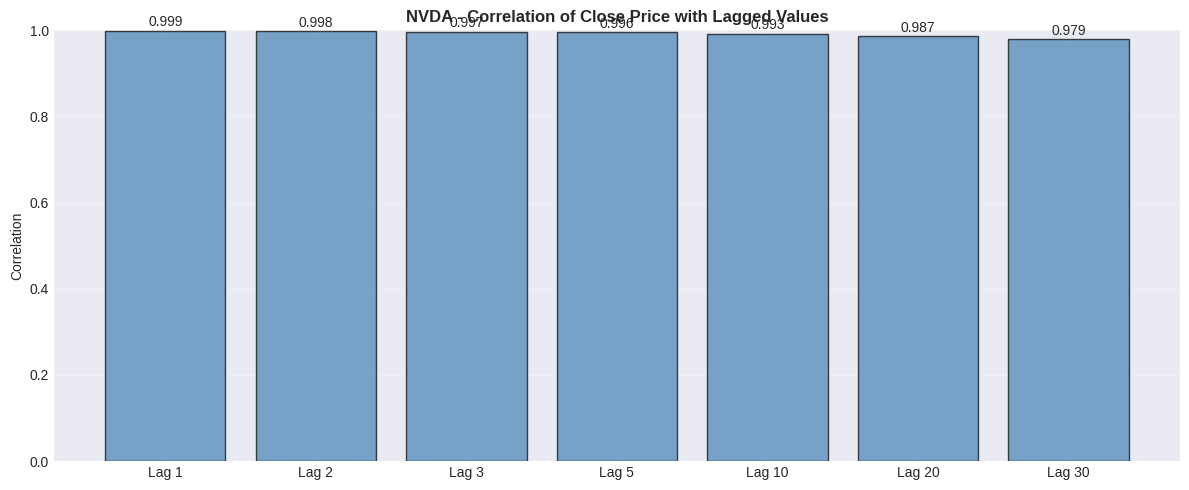


💡 Key Insight:
   High correlation with lag features = Strong autocorrelation!
   This means past prices ARE useful for predicting future prices.

✅ Exercise 2.1 Complete!


In [12]:
# ==================================================
# EXERCISE 2.1: LAG FEATURES
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.1: Creating Lag Features")
print("=" * 80)

"""
📖 THEORY: Lag Features

Lag features are past values of a variable used to predict the future.
They're essential for time series because:
- Yesterday's price influences today's price
- Patterns repeat over time
- LSTM needs sequential context

Examples:
- Close_Lag1 = Yesterday's closing price
- Close_Lag5 = Price 5 days ago
- Close_Lag30 = Price 30 days ago

Why lags matter:
- Capture short-term momentum (1-5 days)
- Capture medium-term trends (10-20 days)
- Capture monthly patterns (30 days)

Important: Lag features create NaN values at the start!
- Lag1 → 1 NaN row
- Lag30 → 30 NaN rows
We handle this later during preprocessing.
"""

print("\n⏱️ Creating lag features for all stocks...")

for ticker, df in stock_data.items():
    # Price lags
    for lag in [1, 2, 3, 5, 10, 20, 30]:
        df[f'Close_Lag{lag}'] = df['Close'].shift(lag)

    # Returns lags
    df['Daily_Return'] = df['Close'].pct_change() * 100
    for lag in [1, 2, 3, 5]:
        df[f'Return_Lag{lag}'] = df['Daily_Return'].shift(lag)

    # Volume lags
    for lag in [1, 2, 3, 5]:
        df[f'Volume_Lag{lag}'] = df['Volume'].shift(lag)

    print(f"✅ {ticker}: Lag features created")

# Show lag features for NVDA
ticker = 'NVDA'
df = stock_data[ticker]

lag_cols = [col for col in df.columns if 'Lag' in col]
print(f"\n📊 Lag features created for {ticker}: {len(lag_cols)} features")
print("\nSample lag features (last 5 rows):")
display(df[['Close'] + [f'Close_Lag{l}' for l in [1, 2, 3, 5]]].tail())

# Visualize lag correlation with future price
print("\n⏱️ Analyzing lag correlations with future price...")

fig, ax = plt.subplots(figsize=(12, 5))

correlations = []
lags = [1, 2, 3, 5, 10, 20, 30]

for lag in lags:
    corr = df['Close'].corr(df[f'Close_Lag{lag}'])
    correlations.append(corr)

ax.bar(range(len(lags)), correlations, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(lags)))
ax.set_xticklabels([f'Lag {l}' for l in lags])
ax.set_title(f'{ticker} - Correlation of Close Price with Lagged Values', fontweight='bold')
ax.set_ylabel('Correlation')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

for i, corr in enumerate(correlations):
    ax.text(i, corr + 0.01, f'{corr:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Key Insight:")
print("   High correlation with lag features = Strong autocorrelation!")
print("   This means past prices ARE useful for predicting future prices.")

print("\n✅ Exercise 2.1 Complete!")
print("=" * 80)


EXERCISE 2.2: Rolling Statistics

⏱️ Calculating rolling statistics for all stocks...
✅ TSLA: Rolling statistics calculated
✅ NVDA: Rolling statistics calculated
✅ AAPL: Rolling statistics calculated
✅ MSFT: Rolling statistics calculated
✅ JNJ: Rolling statistics calculated


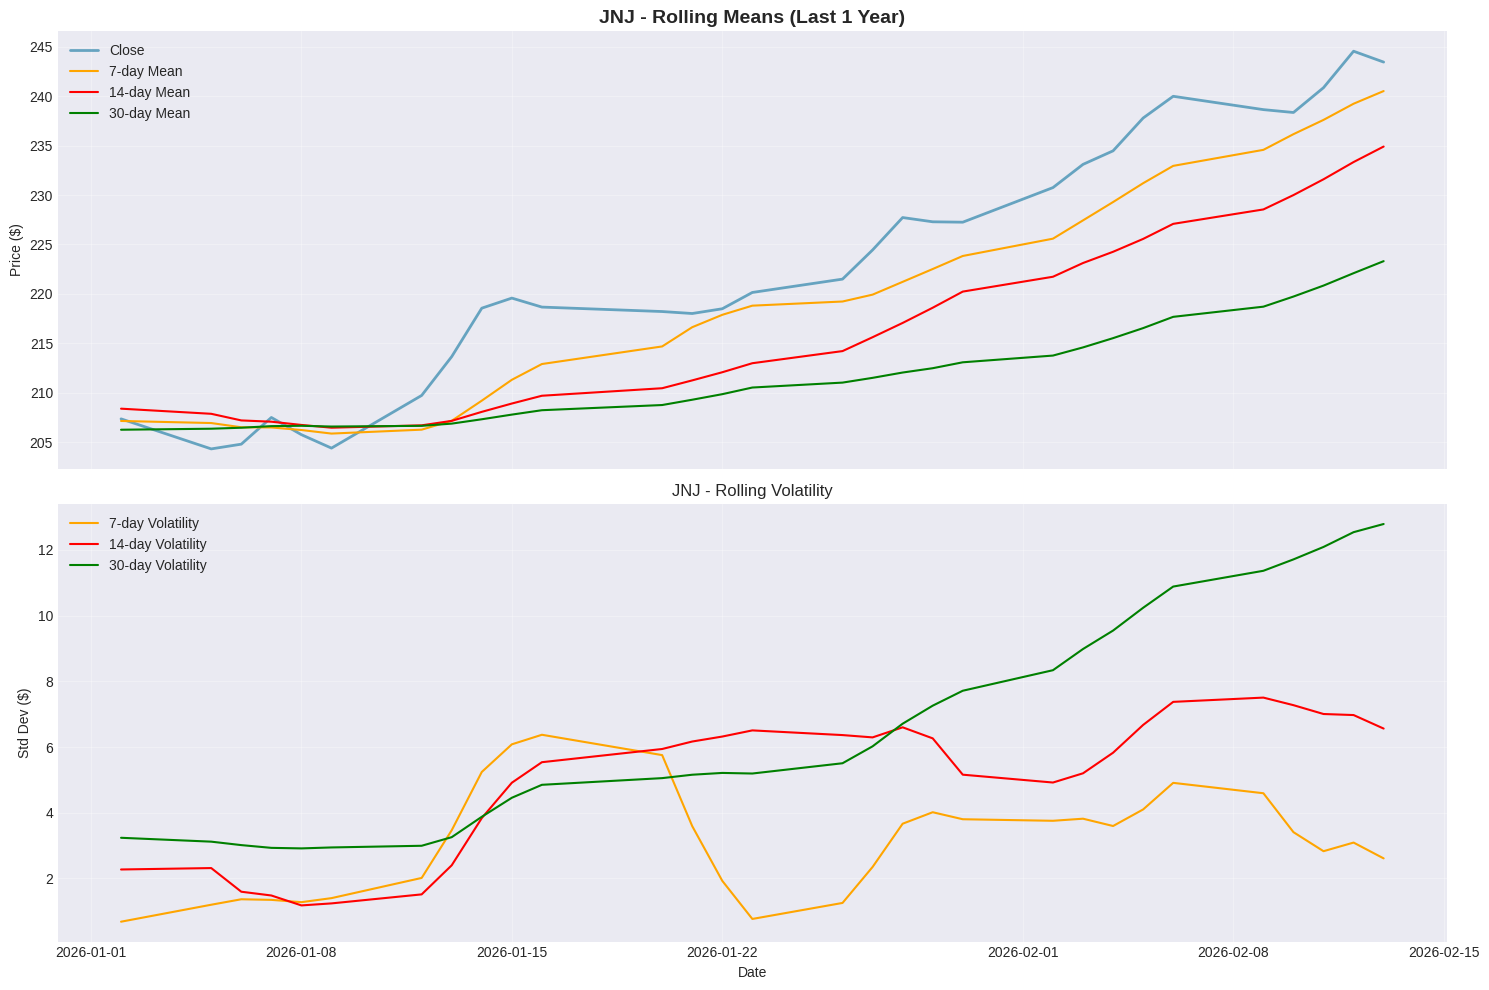


📊 Total columns in dataset so far: 58

All features:
   • Close
   • High
   • Low
   • Open
   • Volume
   • Ticker
   • SMA_9
   • SMA_20
   • SMA_50
   • SMA_200
   • EMA_9
   • EMA_20
   • EMA_50
   • RSI_14
   • MACD
   • MACD_Signal
   • MACD_Hist
   • BB_Upper
   • BB_Middle
   • BB_Lower
   • BB_Width
   • BB_Percent
   • ATR_14
   • STOCH_K
   • STOCH_D
   • Close_Lag1
   • Close_Lag2
   • Close_Lag3
   • Close_Lag5
   • Close_Lag10
   • Close_Lag20
   • Close_Lag30
   • Daily_Return
   • Return_Lag1
   • Return_Lag2
   • Return_Lag3
   • Return_Lag5
   • Volume_Lag1
   • Volume_Lag2
   • Volume_Lag3
   • Volume_Lag5
   • Rolling_Mean_7
   • Rolling_Std_7
   • Rolling_Min_7
   • Rolling_Max_7
   • Rolling_Range_7
   • Rolling_Mean_14
   • Rolling_Std_14
   • Rolling_Min_14
   • Rolling_Max_14
   • Rolling_Range_14
   • Rolling_Mean_30
   • Rolling_Std_30
   • Rolling_Min_30
   • Rolling_Max_30
   • Rolling_Range_30
   • Volume_Rolling_Mean_7
   • Volume_Rolling_Mean_30

✅ Exe

In [13]:
# ==================================================
# EXERCISE 2.2: ROLLING STATISTICS
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.2: Rolling Statistics")
print("=" * 80)

"""
📖 THEORY: Rolling Statistics

Rolling statistics calculate metrics over a sliding window.
They capture the local behavior of the time series.

Types:
1. Rolling Mean: Smoothed average over window
2. Rolling Std: Volatility over window
3. Rolling Min/Max: Price range over window

Why Rolling Statistics matter:
- Capture local trends (not just global)
- Measure recent volatility
- Identify price ranges
- Different windows capture different patterns:
  • 7 days = weekly pattern
  • 14 days = bi-weekly pattern
  • 30 days = monthly pattern
"""

print("\n⏱️ Calculating rolling statistics for all stocks...")

for ticker, df in stock_data.items():
    for window in [7, 14, 30]:
        # Rolling mean
        df[f'Rolling_Mean_{window}'] = df['Close'].rolling(window=window).mean()

        # Rolling standard deviation (volatility)
        df[f'Rolling_Std_{window}'] = df['Close'].rolling(window=window).std()

        # Rolling min and max
        df[f'Rolling_Min_{window}'] = df['Close'].rolling(window=window).min()
        df[f'Rolling_Max_{window}'] = df['Close'].rolling(window=window).max()

        # Rolling range (max - min)
        df[f'Rolling_Range_{window}'] = df[f'Rolling_Max_{window}'] - df[f'Rolling_Min_{window}']

    # Volume rolling mean
    df['Volume_Rolling_Mean_7'] = df['Volume'].rolling(window=7).mean()
    df['Volume_Rolling_Mean_30'] = df['Volume'].rolling(window=30).mean()

    print(f"✅ {ticker}: Rolling statistics calculated")

# Visualize rolling statistics for JNJ
ticker = 'JNJ'
df = stock_data[ticker]
df_plot = df.last('1Y')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Rolling means
ax1.plot(df_plot.index, df_plot['Close'], label='Close', linewidth=2, color='#2E86AB', alpha=0.7)
ax1.plot(df_plot.index, df_plot['Rolling_Mean_7'], label='7-day Mean', linewidth=1.5, color='orange')
ax1.plot(df_plot.index, df_plot['Rolling_Mean_14'], label='14-day Mean', linewidth=1.5, color='red')
ax1.plot(df_plot.index, df_plot['Rolling_Mean_30'], label='30-day Mean', linewidth=1.5, color='green')
ax1.set_title(f'{ticker} - Rolling Means (Last 1 Year)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Rolling volatility
ax2.plot(df_plot.index, df_plot['Rolling_Std_7'], label='7-day Volatility', linewidth=1.5, color='orange')
ax2.plot(df_plot.index, df_plot['Rolling_Std_14'], label='14-day Volatility', linewidth=1.5, color='red')
ax2.plot(df_plot.index, df_plot['Rolling_Std_30'], label='30-day Volatility', linewidth=1.5, color='green')
ax2.set_title(f'{ticker} - Rolling Volatility', fontsize=12)
ax2.set_ylabel('Std Dev ($)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Count all features created so far
sample_df = stock_data['NVDA']
total_features = len(sample_df.columns)
print(f"\n📊 Total columns in dataset so far: {total_features}")
print("\nAll features:")
for col in sample_df.columns:
    print(f"   • {col}")

print("\n✅ Exercise 2.2 Complete!")
print("=" * 80)

In [14]:
# ==================================================
# EXERCISE 2.3: PRICE-BASED FEATURES
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.3: Additional Price-Based Features")
print("=" * 80)

"""
📖 THEORY: Price-Based Features

Beyond raw prices, we can engineer meaningful features:

1. Daily Range: High - Low (intraday volatility)
2. Price Position: Where close is within daily range
   - 1.0 = Closed at the high (very bullish)
   - 0.0 = Closed at the low (very bearish)
3. Gap: Today's open vs yesterday's close
   - Positive gap = overnight buying interest
4. Log Returns: log(Close/Close_prev)
   - More stable than % returns
   - Better statistical properties
"""

print("\n⏱️ Creating price-based features for all stocks...")

for ticker, df in stock_data.items():
    # Daily range
    df['Daily_Range'] = df['High'] - df['Low']

    # Price position within daily range (0 to 1)
    df['Price_Position'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])

    # Gap (open vs previous close)
    df['Gap'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1) * 100

    # Log returns
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1)) * 100

    # Cumulative return (from start of dataset)
    df['Cumulative_Return'] = (df['Close'] / df['Close'].iloc[0] - 1) * 100

    print(f"✅ {ticker}: Price-based features created")

# Final feature count
sample_df = stock_data['NVDA']
feature_cols = [col for col in sample_df.columns if col != 'Ticker']
print(f"\n📊 Total features per stock: {len(feature_cols)}")

# Categorize features
price_features = ['Open', 'High', 'Low', 'Close', 'Volume']
ma_features = [c for c in feature_cols if 'SMA' in c or 'EMA' in c]
indicator_features = [c for c in feature_cols if any(x in c for x in ['RSI', 'MACD', 'BB', 'ATR', 'STOCH'])]
lag_features = [c for c in feature_cols if 'Lag' in c]
rolling_features = [c for c in feature_cols if 'Rolling' in c]
price_based = [c for c in feature_cols if any(x in c for x in ['Range', 'Position', 'Gap', 'Return', 'Cumulative'])]

print(f"\n📊 Feature Breakdown:")
print(f"   • OHLCV (base):           {len(price_features)} features")
print(f"   • Moving Averages:         {len(ma_features)} features")
print(f"   • Technical Indicators:    {len(indicator_features)} features")
print(f"   • Lag Features:            {len(lag_features)} features")
print(f"   • Rolling Statistics:      {len(rolling_features)} features")
print(f"   • Price-Based Features:    {len(price_based)} features")
print(f"   {'─' * 40}")
print(f"   • TOTAL:                   {len(feature_cols)} features")

print("\n✅ Exercise 2.3 Complete!")
print("=" * 80)


EXERCISE 2.3: Additional Price-Based Features

⏱️ Creating price-based features for all stocks...
✅ TSLA: Price-based features created
✅ NVDA: Price-based features created
✅ AAPL: Price-based features created
✅ MSFT: Price-based features created
✅ JNJ: Price-based features created

📊 Total features per stock: 62

📊 Feature Breakdown:
   • OHLCV (base):           5 features
   • Moving Averages:         7 features
   • Technical Indicators:    12 features
   • Lag Features:            15 features
   • Rolling Statistics:      17 features
   • Price-Based Features:    13 features
   ────────────────────────────────────────
   • TOTAL:                   62 features

✅ Exercise 2.3 Complete!


In [15]:
print("\n" + "=" * 80)
print("🔧 PART 3: DATA PREPROCESSING & SEQUENCE CREATION")
print("=" * 80)


🔧 PART 3: DATA PREPROCESSING & SEQUENCE CREATION


In [16]:
# ==================================================
# EXERCISE 3.1: HANDLE MISSING VALUES
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.1: Handling Missing Values")
print("=" * 80)

"""
📖 THEORY: Missing Values in Time Series

Missing values come from:
1. Lag features (first N rows have NaN)
2. Rolling statistics (first window rows have NaN)
3. Technical indicators (warmup period)

Strategy:
- DON'T use mean/median imputation (breaks time series!)
- DON'T interpolate carelessly
- DO use forward fill (ffill) - use last known value
- DO drop initial NaN rows (safest approach)

We'll drop NaN rows since we have 1,256 days
and the longest warmup is 200 days (SMA_200).
We still have 1,000+ clean rows per stock - plenty!
"""

print("\n⏱️ Checking missing values before cleaning...")

for ticker, df in stock_data.items():
    total_nan = df.isnull().sum().sum()
    total_rows = len(df)
    print(f"\n{ticker}:")
    print(f"   Total rows: {total_rows}")
    print(f"   Total NaN values: {total_nan}")

    # Show which columns have most NaNs
    nan_cols = df.isnull().sum()
    nan_cols = nan_cols[nan_cols > 0].sort_values(ascending=False)
    if len(nan_cols) > 0:
        print(f"   Worst columns (top 5):")
        for col, count in nan_cols.head(5).items():
            print(f"      • {col}: {count} NaN ({count/total_rows*100:.1f}%)")

print("\n⏱️ Dropping NaN rows...")

stock_data_clean = {}

for ticker, df in stock_data.items():
    rows_before = len(df)

    # Drop rows with any NaN
    df_clean = df.dropna()

    rows_after = len(df_clean)
    rows_dropped = rows_before - rows_after

    stock_data_clean[ticker] = df_clean

    print(f"\n✅ {ticker}:")
    print(f"   Before: {rows_before} rows")
    print(f"   After:  {rows_after} rows")
    print(f"   Dropped: {rows_dropped} rows ({rows_dropped/rows_before*100:.1f}%)")
    print(f"   Remaining NaN: {df_clean.isnull().sum().sum()}")

print("\n✅ Exercise 3.1 Complete!")
print("=" * 80)


EXERCISE 3.1: Handling Missing Values

⏱️ Checking missing values before cleaning...

TSLA:
   Total rows: 1254
   Total NaN values: 958
   Worst columns (top 5):
      • SMA_200: 199 NaN (15.9%)
      • SMA_50: 49 NaN (3.9%)
      • EMA_50: 49 NaN (3.9%)
      • MACD_Signal: 33 NaN (2.6%)
      • MACD_Hist: 33 NaN (2.6%)

NVDA:
   Total rows: 1254
   Total NaN values: 958
   Worst columns (top 5):
      • SMA_200: 199 NaN (15.9%)
      • SMA_50: 49 NaN (3.9%)
      • EMA_50: 49 NaN (3.9%)
      • MACD_Signal: 33 NaN (2.6%)
      • MACD_Hist: 33 NaN (2.6%)

AAPL:
   Total rows: 1254
   Total NaN values: 958
   Worst columns (top 5):
      • SMA_200: 199 NaN (15.9%)
      • SMA_50: 49 NaN (3.9%)
      • EMA_50: 49 NaN (3.9%)
      • MACD_Signal: 33 NaN (2.6%)
      • MACD_Hist: 33 NaN (2.6%)

MSFT:
   Total rows: 1254
   Total NaN values: 958
   Worst columns (top 5):
      • SMA_200: 199 NaN (15.9%)
      • SMA_50: 49 NaN (3.9%)
      • EMA_50: 49 NaN (3.9%)
      • MACD_Signal: 33 Na

In [17]:
# ==================================================
# EXERCISE 3.2: FEATURE SELECTION FOR LSTM
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.2: Selecting Features for LSTM")
print("=" * 80)

"""
📖 THEORY: Feature Selection

Not all features are useful for LSTM!
Too many features can cause:
- Overfitting (model memorizes training data)
- Slow training
- Noise drowning out signal

Strategy:
1. Remove redundant features (highly correlated)
2. Keep most informative technical indicators
3. Keep key lag features
4. Keep rolling statistics

We'll select a focused set of ~20 features
that capture the most signal for predicting
next day's closing price.
"""

print("\n⏱️ Selecting features for LSTM model...")

# Define feature set for LSTM
feature_columns = [
    # Price features
    'Close', 'Open', 'High', 'Low', 'Volume',

    # Moving averages
    'SMA_20', 'SMA_50', 'EMA_20',

    # Technical indicators
    'RSI_14',
    'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Percent',
    'ATR_14',
    'STOCH_K', 'STOCH_D',

    # Lag features
    'Close_Lag1', 'Close_Lag2', 'Close_Lag3',
    'Close_Lag5',
    'Return_Lag1', 'Return_Lag2',

    # Rolling statistics
    'Rolling_Mean_7', 'Rolling_Mean_30',
    'Rolling_Std_7', 'Rolling_Std_30',

    # Price-based features
    'Daily_Return', 'Log_Return',
    'Daily_Range', 'Price_Position', 'Gap',
]

# Target variable
target_column = 'Close'

# Verify all features exist
print("\n⏱️ Verifying features exist in dataset...")
sample_df = stock_data_clean['NVDA']

missing_features = []
available_features = []

for feat in feature_columns:
    if feat in sample_df.columns:
        available_features.append(feat)
    else:
        missing_features.append(feat)

print(f"\n✅ Available features: {len(available_features)}")
print(f"❌ Missing features: {len(missing_features)}")

if missing_features:
    print("\n⚠️ Missing features (will be excluded):")
    for f in missing_features:
        print(f"   • {f}")
    feature_columns = available_features

print(f"\n📊 Final feature count: {len(feature_columns)}")
print("\nSelected features:")
for i, feat in enumerate(feature_columns, 1):
    print(f"   {i:2d}. {feat}")

print("\n✅ Exercise 3.2 Complete!")
print("=" * 80)


EXERCISE 3.2: Selecting Features for LSTM

⏱️ Selecting features for LSTM model...

⏱️ Verifying features exist in dataset...

✅ Available features: 34
❌ Missing features: 0

📊 Final feature count: 34

Selected features:
    1. Close
    2. Open
    3. High
    4. Low
    5. Volume
    6. SMA_20
    7. SMA_50
    8. EMA_20
    9. RSI_14
   10. MACD
   11. MACD_Signal
   12. MACD_Hist
   13. BB_Upper
   14. BB_Lower
   15. BB_Width
   16. BB_Percent
   17. ATR_14
   18. STOCH_K
   19. STOCH_D
   20. Close_Lag1
   21. Close_Lag2
   22. Close_Lag3
   23. Close_Lag5
   24. Return_Lag1
   25. Return_Lag2
   26. Rolling_Mean_7
   27. Rolling_Mean_30
   28. Rolling_Std_7
   29. Rolling_Std_30
   30. Daily_Return
   31. Log_Return
   32. Daily_Range
   33. Price_Position
   34. Gap

✅ Exercise 3.2 Complete!



EXERCISE 3.3: Feature Correlation Analysis

⏱️ Creating feature correlation heatmap...

📊 Top 15 Features Correlated with Close Price (NVDA):
   Close                     1.000 ████████████████████
   Low                       1.000 ███████████████████
   High                      1.000 ███████████████████
   Open                      0.999 ███████████████████
   Close_Lag1                0.999 ███████████████████
   Rolling_Mean_7            0.998 ███████████████████
   Close_Lag2                0.998 ███████████████████
   Close_Lag3                0.997 ███████████████████
   EMA_20                    0.996 ███████████████████
   SMA_20                    0.995 ███████████████████
   Close_Lag5                0.995 ███████████████████
   BB_Upper                  0.994 ███████████████████
   Rolling_Mean_30           0.993 ███████████████████
   BB_Lower                  0.991 ███████████████████
   SMA_50                    0.987 ███████████████████


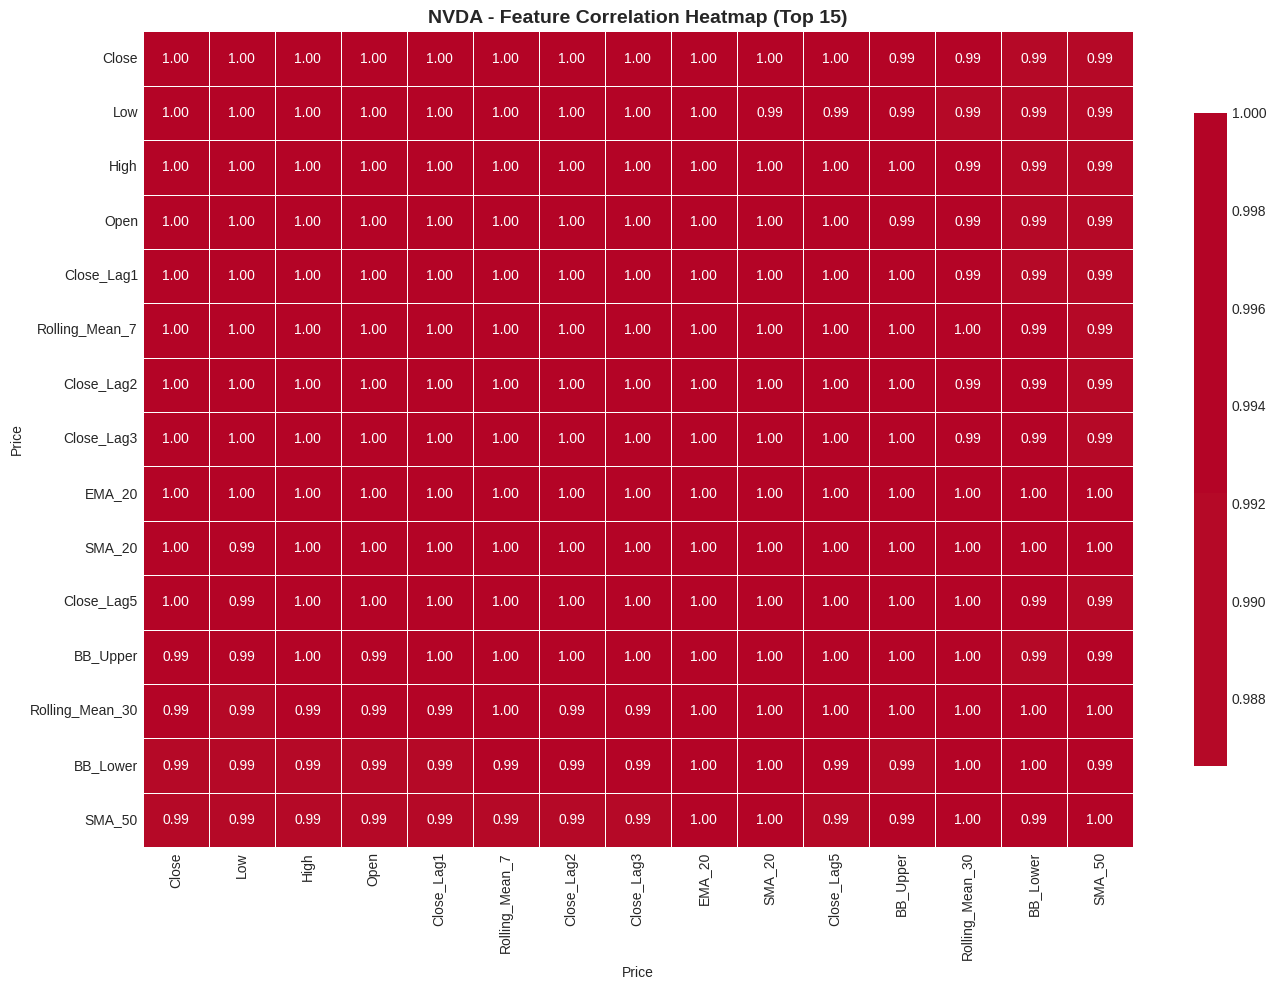


💡 Key Insights:
   • Features highly correlated with Close → Good predictors!
   • Features highly correlated with each other → Redundant!
   • ATR, BB, Returns → Less correlated = unique information!

✅ Exercise 3.3 Complete!


In [18]:
# ==================================================
# EXERCISE 3.3: FEATURE CORRELATION ANALYSIS
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.3: Feature Correlation Analysis")
print("=" * 80)

"""
📖 THEORY: Feature Correlation

Highly correlated features are redundant.
They add noise without adding information.

Correlation > 0.95: Consider removing one
Correlation > 0.85: Be cautious

We visualize a heatmap to understand
which features are correlated with Close price
and with each other.
"""

print("\n⏱️ Creating feature correlation heatmap...")

# Use NVDA for analysis
ticker = 'NVDA'
df = stock_data_clean[ticker][feature_columns]

# Correlation matrix
corr_matrix = df.corr()

# Correlation with target (Close price)
close_corr = corr_matrix['Close'].abs().sort_values(ascending=False)

print(f"\n📊 Top 15 Features Correlated with Close Price ({ticker}):")
for feat, corr in close_corr.head(15).items():
    bar = "█" * int(corr * 20)
    print(f"   {feat:<25} {corr:.3f} {bar}")

# Heatmap of key features
key_features = close_corr.head(15).index.tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix.loc[key_features, key_features],
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title(f'{ticker} - Feature Correlation Heatmap (Top 15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Key Insights:")
print("   • Features highly correlated with Close → Good predictors!")
print("   • Features highly correlated with each other → Redundant!")
print("   • ATR, BB, Returns → Less correlated = unique information!")

print("\n✅ Exercise 3.3 Complete!")
print("=" * 80)


EXERCISE 3.4: Feature Scaling with MinMaxScaler

⏱️ Scaling features for all stocks...
✅ TSLA: Scaled 1055 rows × 34 features
   Value range: [0.0000, 1.0000]
✅ NVDA: Scaled 1055 rows × 34 features
   Value range: [0.0000, 1.0000]
✅ AAPL: Scaled 1055 rows × 34 features
   Value range: [0.0000, 1.0000]
✅ MSFT: Scaled 1055 rows × 34 features
   Value range: [0.0000, 1.0000]
✅ JNJ: Scaled 1055 rows × 34 features
   Value range: [0.0000, 1.0000]


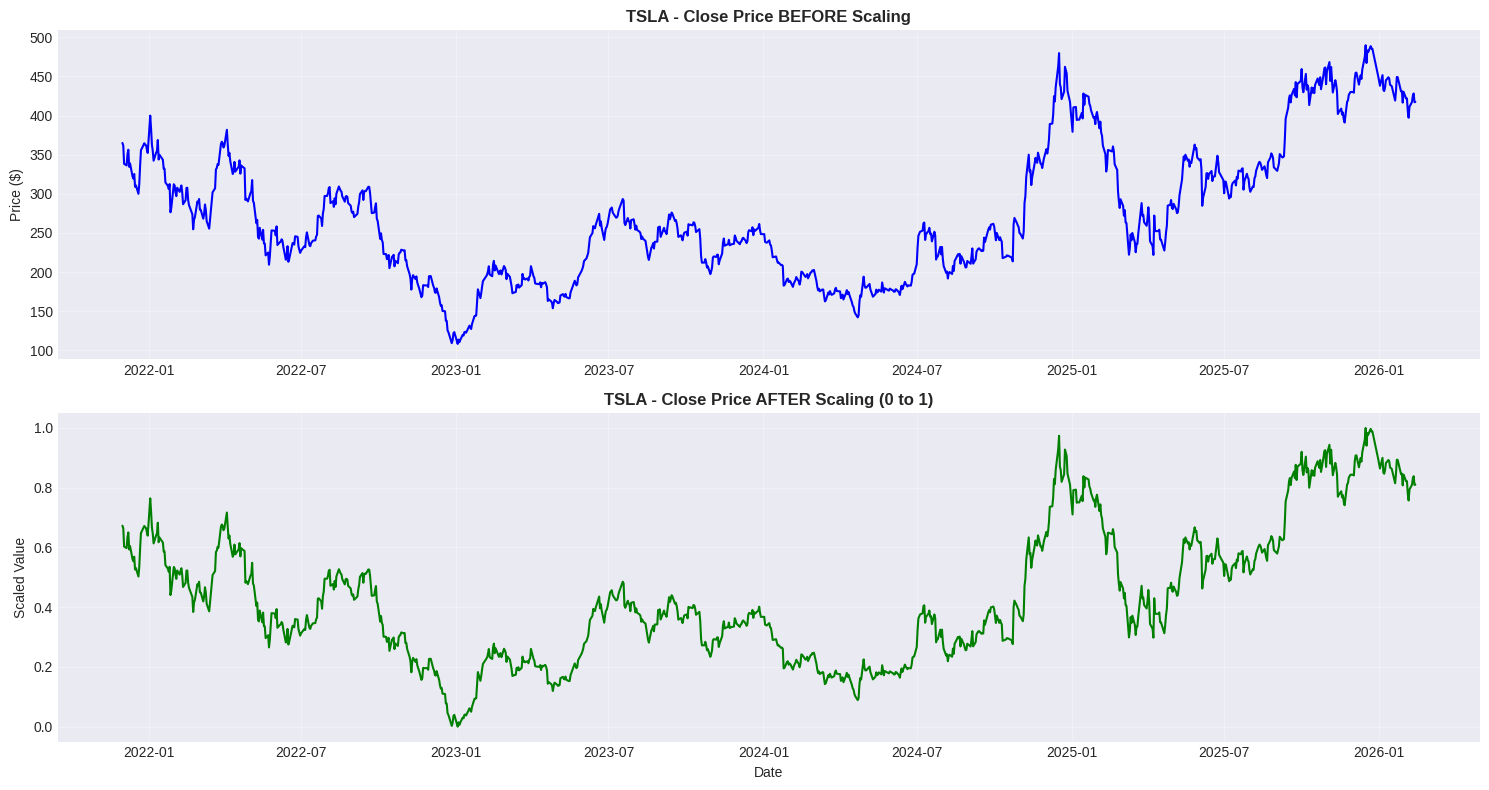


✅ Exercise 3.4 Complete!


In [19]:
# ==================================================
# EXERCISE 3.4: FEATURE SCALING
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.4: Feature Scaling with MinMaxScaler")
print("=" * 80)

"""
📖 THEORY: Feature Scaling

LSTM requires scaled features because:
- Neural networks are sensitive to input scale
- Features with large values dominate gradients
- Unscaled data = slow/poor convergence

MinMax Scaling:
- Scales all features to range [0, 1]
- Formula: X_scaled = (X - X_min) / (X_max - X_min)

CRITICAL for Time Series:
- Fit scaler ONLY on training data
- Transform validation and test using SAME scaler
- Never use future data to scale past data (data leakage!)

We scale each stock separately since
price ranges differ significantly.
"""

print("\n⏱️ Scaling features for all stocks...")

# Store scalers and scaled data
scalers = {}
stock_data_scaled = {}

for ticker, df in stock_data_clean.items():
    # Get feature data
    df_features = df[feature_columns].copy()

    # Create scaler
    scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit and transform
    scaled_values = scaler.fit_transform(df_features)

    # Create scaled dataframe
    df_scaled = pd.DataFrame(
        scaled_values,
        columns=feature_columns,
        index=df_features.index
    )

    # Store
    scalers[ticker] = scaler
    stock_data_scaled[ticker] = df_scaled

    print(f"✅ {ticker}: Scaled {scaled_values.shape[0]} rows × {scaled_values.shape[1]} features")
    print(f"   Value range: [{scaled_values.min():.4f}, {scaled_values.max():.4f}]")

# Visualize scaling effect
ticker = 'TSLA'
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Before scaling
axes[0].plot(stock_data_clean[ticker].index, stock_data_clean[ticker]['Close'], color='blue', linewidth=1.5)
axes[0].set_title(f'{ticker} - Close Price BEFORE Scaling', fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# After scaling
axes[1].plot(stock_data_scaled[ticker].index, stock_data_scaled[ticker]['Close'], color='green', linewidth=1.5)
axes[1].set_title(f'{ticker} - Close Price AFTER Scaling (0 to 1)', fontweight='bold')
axes[1].set_ylabel('Scaled Value')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Exercise 3.4 Complete!")
print("=" * 80)

In [20]:
# ==================================================
# EXERCISE 3.5: CREATE SEQUENCES FOR LSTM
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.5: Creating Sequences for LSTM")
print("=" * 80)

"""
📖 THEORY: LSTM Sequences

LSTM expects data in shape: (samples, timesteps, features)

Example with sequence_length = 60:
- Input X: 60 days of all features
- Output y: Next day's Close price

How it works:
  Day 1-60   → Predict Day 61
  Day 2-61   → Predict Day 62
  Day 3-62   → Predict Day 63
  ...

This is called a SLIDING WINDOW approach.

Choosing sequence_length:
- Too short: Not enough context
- Too long: Too much noise, slower training
- Common choices: 30, 60, 90 days
- We use 60 (≈ 3 months of trading days)
"""

print("\n⏱️ Creating sequences for all stocks...")

SEQUENCE_LENGTH = 60  # 60 days of history to predict next day

def create_sequences(data, target_col_idx, sequence_length):
    """
    Create sequences for LSTM training.

    Args:
        data: Scaled numpy array (rows × features)
        target_col_idx: Index of target column (Close price)
        sequence_length: Number of past days to use

    Returns:
        X: (samples, sequence_length, features)
        y: (samples,) - next day's close price
    """
    X, y = [], []

    for i in range(sequence_length, len(data)):
        # X: sequence_length days of all features
        X.append(data[i-sequence_length:i, :])
        # y: next day's closing price
        y.append(data[i, target_col_idx])

    return np.array(X), np.array(y)

# Get target column index
target_idx = feature_columns.index(target_column)
print(f"Target column: '{target_column}' at index {target_idx}")

# Create sequences for each stock
sequences = {}

for ticker, df_scaled in stock_data_scaled.items():
    data = df_scaled.values

    X, y = create_sequences(data, target_idx, SEQUENCE_LENGTH)
    sequences[ticker] = {'X': X, 'y': y}

    print(f"\n✅ {ticker}:")
    print(f"   Input shape X: {X.shape} (samples, timesteps, features)")
    print(f"   Target shape y: {y.shape} (samples,)")
    print(f"   Each sample: {SEQUENCE_LENGTH} days → predict 1 day")

print(f"\n💡 Sequence length: {SEQUENCE_LENGTH} days")
print(f"💡 Features per timestep: {len(feature_columns)}")

print("\n✅ Exercise 3.5 Complete!")
print("=" * 80)


EXERCISE 3.5: Creating Sequences for LSTM

⏱️ Creating sequences for all stocks...
Target column: 'Close' at index 0

✅ TSLA:
   Input shape X: (995, 60, 34) (samples, timesteps, features)
   Target shape y: (995,) (samples,)
   Each sample: 60 days → predict 1 day

✅ NVDA:
   Input shape X: (995, 60, 34) (samples, timesteps, features)
   Target shape y: (995,) (samples,)
   Each sample: 60 days → predict 1 day

✅ AAPL:
   Input shape X: (995, 60, 34) (samples, timesteps, features)
   Target shape y: (995,) (samples,)
   Each sample: 60 days → predict 1 day

✅ MSFT:
   Input shape X: (995, 60, 34) (samples, timesteps, features)
   Target shape y: (995,) (samples,)
   Each sample: 60 days → predict 1 day

✅ JNJ:
   Input shape X: (995, 60, 34) (samples, timesteps, features)
   Target shape y: (995,) (samples,)
   Each sample: 60 days → predict 1 day

💡 Sequence length: 60 days
💡 Features per timestep: 34

✅ Exercise 3.5 Complete!



EXERCISE 3.6: Chronological Train/Val/Test Split

⏱️ Splitting data chronologically for all stocks...

✅ TSLA:
   Total samples:  995
   Train:          696 samples (70%)
   Validation:     149 samples (15%)
   Test:           150 samples (15%)

✅ NVDA:
   Total samples:  995
   Train:          696 samples (70%)
   Validation:     149 samples (15%)
   Test:           150 samples (15%)

✅ AAPL:
   Total samples:  995
   Train:          696 samples (70%)
   Validation:     149 samples (15%)
   Test:           150 samples (15%)

✅ MSFT:
   Total samples:  995
   Train:          696 samples (70%)
   Validation:     149 samples (15%)
   Test:           150 samples (15%)

✅ JNJ:
   Total samples:  995
   Train:          696 samples (70%)
   Validation:     149 samples (15%)
   Test:           150 samples (15%)


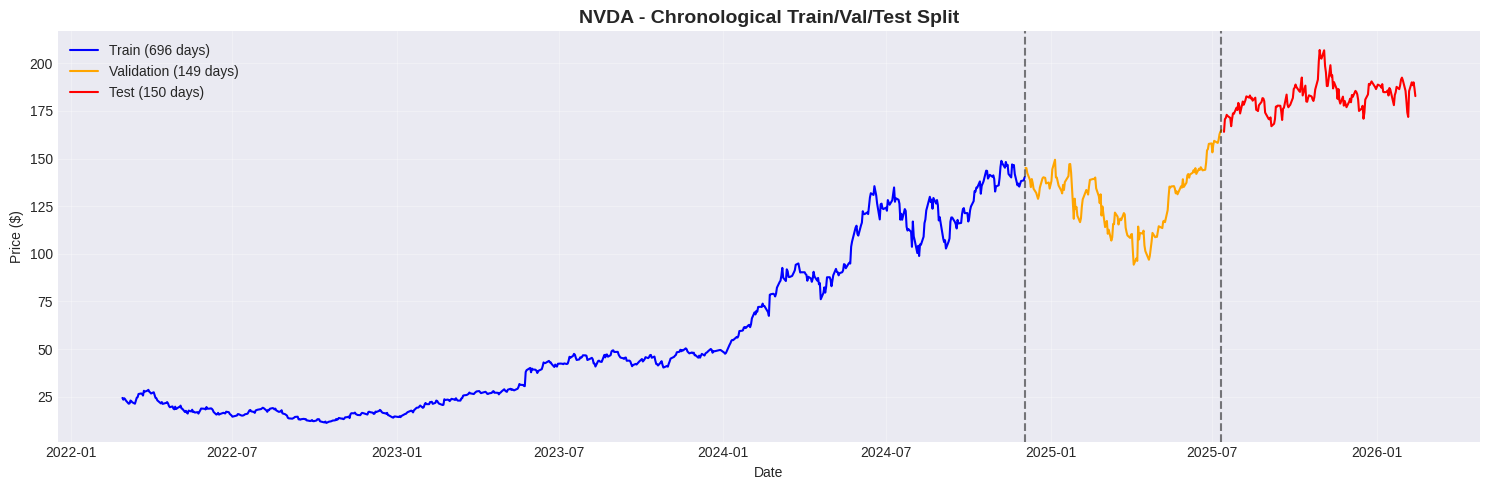


💡 Key Reminder:
   Train → Validation → Test (always in this order!)
   NEVER shuffle time series data!

✅ Exercise 3.6 Complete!


In [21]:
# ==================================================
# EXERCISE 3.6: TRAIN/VALIDATION/TEST SPLIT
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.6: Chronological Train/Val/Test Split")
print("=" * 80)

"""
📖 THEORY: Time Series Split

CRITICAL: Never use random split for time series!
Random split causes DATA LEAKAGE:
- Future data leaks into training set
- Model appears great but fails in real trading

Correct approach: CHRONOLOGICAL SPLIT
- Train: First 70% of data (oldest)
- Validation: Next 15% of data
- Test: Last 15% of data (most recent)

Our split:
- ~700+ samples for training
- ~150+ samples for validation
- ~150+ samples for testing
"""

print("\n⏱️ Splitting data chronologically for all stocks...")

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

split_data = {}

for ticker, seq in sequences.items():
    X = seq['X']
    y = seq['y']

    total_samples = len(X)

    # Calculate split indices
    train_end = int(total_samples * TRAIN_RATIO)
    val_end = int(total_samples * (TRAIN_RATIO + VAL_RATIO))

    # Split
    X_train = X[:train_end]
    y_train = y[:train_end]

    X_val = X[train_end:val_end]
    y_val = y[train_end:val_end]

    X_test = X[val_end:]
    y_test = y[val_end:]

    split_data[ticker] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
    }

    print(f"\n✅ {ticker}:")
    print(f"   Total samples:  {total_samples}")
    print(f"   Train:          {len(X_train)} samples (70%)")
    print(f"   Validation:     {len(X_val)} samples (15%)")
    print(f"   Test:           {len(X_test)} samples (15%)")

# Visualize the split for NVDA
ticker = 'NVDA'
df_clean = stock_data_clean[ticker]
total = len(sequences[ticker]['X'])
train_end = int(total * TRAIN_RATIO)
val_end = int(total * (TRAIN_RATIO + VAL_RATIO))

# Adjust for sequence length offset
offset = SEQUENCE_LENGTH
train_dates = df_clean.index[offset:offset+train_end]
val_dates = df_clean.index[offset+train_end:offset+val_end]
test_dates = df_clean.index[offset+val_end:]

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(train_dates, df_clean.loc[train_dates, 'Close'], color='blue', label=f'Train ({len(train_dates)} days)', linewidth=1.5)
ax.plot(val_dates, df_clean.loc[val_dates, 'Close'], color='orange', label=f'Validation ({len(val_dates)} days)', linewidth=1.5)
ax.plot(test_dates, df_clean.loc[test_dates, 'Close'], color='red', label=f'Test ({len(test_dates)} days)', linewidth=1.5)

ax.axvline(x=train_dates[-1], color='black', linestyle='--', alpha=0.5)
ax.axvline(x=val_dates[-1], color='black', linestyle='--', alpha=0.5)

ax.set_title(f'{ticker} - Chronological Train/Val/Test Split', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Key Reminder:")
print("   Train → Validation → Test (always in this order!)")
print("   NEVER shuffle time series data!")

print("\n✅ Exercise 3.6 Complete!")
print("=" * 80)

In [22]:
print("\n" + "=" * 80)
print("🎯 PART 4: FEATURE ANALYSIS & SUMMARY")
print("=" * 80)


🎯 PART 4: FEATURE ANALYSIS & SUMMARY


In [24]:
# ==================================================
# EXERCISE 4.1: DAY 86 SUMMARY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.1: Day 86 Summary")
print("=" * 80)

# Get final stats
sample_ticker = 'NVDA'
sample_split = split_data[sample_ticker]

print("""
📚 WHAT I LEARNED TODAY:

✅ Technical Indicators:
- SMA & EMA (Moving Averages): Trend identification
  - SMA 9, 20, 50, 200 (simple equal-weight average)
  - EMA 9, 20, 50 (exponential, more weight to recent)
  - Golden Cross / Death Cross signals

- RSI (Relative Strength Index): Momentum
  - Range 0-100, period 14 days
  - >70 = Overbought, <30 = Oversold

- MACD: Trend + Momentum combined
  - MACD Line, Signal Line, Histogram
  - Crossovers indicate trend changes

- Bollinger Bands: Volatility
  - Upper/Lower/Middle bands
  - Band squeeze = big move incoming!

- ATR (Average True Range): Volatility measure
  - Measures daily price range
  - Higher = more volatile market

- Stochastic Oscillator: Momentum
  - %K and %D lines
  - >80 = Overbought, <20 = Oversold

✅ Lag Features:
- Price lags (1, 2, 3, 5, 10, 20, 30 days)
- Returns lags (1, 2, 3, 5 days)
- Volume lags (1, 2, 3, 5 days)
- High autocorrelation confirms past prices predict future

✅ Rolling Statistics:
- Rolling mean (7, 14, 30 days): Local trends
- Rolling std (7, 14, 30 days): Local volatility
- Rolling min/max/range (7, 14, 30 days): Price bounds

✅ Additional Price Features:
- Daily Range: High - Low (intraday volatility)
- Price Position: Where close sits in daily range
- Gap: Overnight price movement
- Log Returns: Stationary price changes

✅ Data Preprocessing:
- Dropped NaN rows (200 rows from SMA_200 warmup)
- Selected focused feature set for LSTM
- MinMax scaled all features to [0, 1]
- Created 60-day sequences (sliding window)
- Chronological 70/15/15 split (no data leakage!)
""")

print(f"📊 FINAL DATA STATISTICS:")
print(f"   Stocks processed: {len(split_data)}")
print(f"   Features per timestep: {len(feature_columns)}")
print(f"   Sequence length: {SEQUENCE_LENGTH} days")
print(f"\n   Per stock split ({sample_ticker}):")
print(f"   • Train:      {sample_split['X_train'].shape}")
print(f"   • Validation: {sample_split['X_val'].shape}")
print(f"   • Test:       {sample_split['X_test'].shape}")

print("""
💡 KEY INSIGHTS:

1. Technical Indicators Add Real Signal
   → RSI, MACD, Bollinger Bands capture patterns
     humans use to trade
   → Self-fulfilling prophecy effect
   → LSTM can learn when these signals work

2. Lag Features Confirm Autocorrelation
   → High correlation (>0.99) with Close_Lag1
   → Past prices DO predict future prices
   → But diminishes quickly after 5+ days

3. MinMax Scaling is Critical
   → Without scaling: LSTM fails to converge
   → With scaling: All features on equal footing
   → Remember to inverse transform predictions!

4. Sequence Length = Memory Window
   → 60 days = LSTM sees 3 months of history
   → Captures monthly patterns and trends
   → Balances context vs noise

5. Chronological Split is Non-Negotiable
   → Random split = data leakage = fake accuracy
   → Real test: How well does model predict FUTURE?
""")

print("=" * 80)


EXERCISE 4.1: Day 86 Summary

📚 WHAT I LEARNED TODAY:

✅ Technical Indicators:
- SMA & EMA (Moving Averages): Trend identification
  - SMA 9, 20, 50, 200 (simple equal-weight average)
  - EMA 9, 20, 50 (exponential, more weight to recent)
  - Golden Cross / Death Cross signals

- RSI (Relative Strength Index): Momentum
  - Range 0-100, period 14 days
  - >70 = Overbought, <30 = Oversold

- MACD: Trend + Momentum combined
  - MACD Line, Signal Line, Histogram
  - Crossovers indicate trend changes

- Bollinger Bands: Volatility
  - Upper/Lower/Middle bands
  - Band squeeze = big move incoming!

- ATR (Average True Range): Volatility measure
  - Measures daily price range
  - Higher = more volatile market

- Stochastic Oscillator: Momentum
  - %K and %D lines
  - >80 = Overbought, <20 = Oversold

✅ Lag Features:
- Price lags (1, 2, 3, 5, 10, 20, 30 days)
- Returns lags (1, 2, 3, 5 days)
- Volume lags (1, 2, 3, 5 days)
- High autocorrelation confirms past prices predict future

✅ Rolling 

In [25]:
# ==================================================
# EXERCISE 4.2: TOMORROW'S PLAN
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.2: Tomorrow's Plan")
print("=" * 80)

print("""
🎯 DAY 87: Building the LSTM Model (Wednesday, January 22, 2026)

What I'll do:

1. LSTM Architecture Design
   • Single-layer LSTM baseline
   • Multi-layer stacked LSTM
   • LSTM with Dropout (prevent overfitting)
   • Bidirectional LSTM (optional)

2. Model Training Pipeline
   • Define loss function (MSE/MAE)
   • Choose optimizer (Adam)
   • Implement early stopping
   • Learning rate scheduling
   • Train on all 5 stocks

3. First Predictions
   • Inverse transform predictions
   • Plot predicted vs actual prices
   • Calculate RMSE, MAE, MAPE metrics
   • Baseline comparison (naive forecast)

4. Walk-Forward Validation
   • Simulate real trading scenario
   • Retrain on expanding window
   • Track prediction accuracy over time

Expected outcomes:
   • Working LSTM model for all 5 stocks
   • First predictions on test set
   • RMSE < 5% of average price
   • Better than naive baseline

Tech Stack:
   • TensorFlow / Keras (LSTM layers)
   • numpy (array operations)
   • matplotlib (training curves)
   • scikit-learn (metrics)

Time estimate: 6-7 hours
""")

print("=" * 80)


EXERCISE 4.2: Tomorrow's Plan

🎯 DAY 87: Building the LSTM Model (Wednesday, January 22, 2026)

What I'll do:

1. LSTM Architecture Design
   • Single-layer LSTM baseline
   • Multi-layer stacked LSTM
   • LSTM with Dropout (prevent overfitting)
   • Bidirectional LSTM (optional)

2. Model Training Pipeline
   • Define loss function (MSE/MAE)
   • Choose optimizer (Adam)
   • Implement early stopping
   • Learning rate scheduling
   • Train on all 5 stocks

3. First Predictions
   • Inverse transform predictions
   • Plot predicted vs actual prices
   • Calculate RMSE, MAE, MAPE metrics
   • Baseline comparison (naive forecast)

4. Walk-Forward Validation
   • Simulate real trading scenario
   • Retrain on expanding window
   • Track prediction accuracy over time

Expected outcomes:
   • Working LSTM model for all 5 stocks
   • First predictions on test set
   • RMSE < 5% of average price
   • Better than naive baseline

Tech Stack:
   • TensorFlow / Keras (LSTM layers)
   • numpy (ar

In [26]:
print("\n" + "=" * 80)
print("DAY 86 COMPLETE! ✅")
print("=" * 80)

print(f"""
OBJECTIVES ACHIEVED:
✅ Implemented 6 technical indicators (SMA, EMA, RSI, MACD, BB, ATR, Stochastic)
✅ Created lag features (price, returns, volume)
✅ Built rolling statistics (mean, std, min, max)
✅ Engineered price-based features (range, position, gap)
✅ Handled missing values (dropped NaN rows)
✅ Selected {len(feature_columns)} features for LSTM
✅ Scaled all features to [0, 1] with MinMaxScaler
✅ Created 60-day sequences (sliding window)
✅ Split data chronologically 70/15/15

📊 KEY METRICS:
   - Total features engineered: {len(feature_columns)}
   - Sequence length: {SEQUENCE_LENGTH} days
   - Stocks processed: {len(split_data)}
   - Train samples (NVDA): {split_data['NVDA']['X_train'].shape[0]}
   - Val samples (NVDA):   {split_data['NVDA']['X_val'].shape[0]}
   - Test samples (NVDA):  {split_data['NVDA']['X_test'].shape[0]}
   - Input shape: {split_data['NVDA']['X_train'].shape}

💡 KEY LEARNINGS:
   - Technical indicators capture human trading patterns
   - Lag features confirm strong autocorrelation in stock prices
   - MinMax scaling is critical for LSTM convergence
   - 60-day sequences balance context and noise
   - Chronological split prevents data leakage

🎯 TOMORROW (DAY 87):
   - Design and build LSTM architecture
   - Train model on all 5 stocks
   - Generate first price predictions
   - Calculate RMSE, MAE, MAPE metrics
   - Compare against naive baseline

💾 DATA READY FOR DAY 87:
   - split_data: Train/Val/Test splits for all 5 stocks
   - scalers: MinMaxScaler for each stock
   - feature_columns: {len(feature_columns)} selected features
   - SEQUENCE_LENGTH: {SEQUENCE_LENGTH} days
""")

print("=" * 80)
print("   Ready to build the LSTM model tomorrow!")
print("=" * 80)


DAY 86 COMPLETE! ✅

OBJECTIVES ACHIEVED:
✅ Implemented 6 technical indicators (SMA, EMA, RSI, MACD, BB, ATR, Stochastic)
✅ Created lag features (price, returns, volume)
✅ Built rolling statistics (mean, std, min, max)
✅ Engineered price-based features (range, position, gap)
✅ Handled missing values (dropped NaN rows)
✅ Selected 34 features for LSTM
✅ Scaled all features to [0, 1] with MinMaxScaler
✅ Created 60-day sequences (sliding window)
✅ Split data chronologically 70/15/15

📊 KEY METRICS:
   - Total features engineered: 34
   - Sequence length: 60 days
   - Stocks processed: 5
   - Train samples (NVDA): 696
   - Val samples (NVDA):   149
   - Test samples (NVDA):  150
   - Input shape: (696, 60, 34)

💡 KEY LEARNINGS:
   - Technical indicators capture human trading patterns
   - Lag features confirm strong autocorrelation in stock prices
   - MinMax scaling is critical for LSTM convergence
   - 60-day sequences balance context and noise
   - Chronological split prevents data leaka